# Import Libraries

In [1]:
!pip install thefuzz

In [2]:
import re
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import itertools
import matplotlib.patches as mpatches
import seaborn as sns
from itertools import combinations, permutations
from tqdm import tqdm
import csv
import mlxtend
from mlxtend.frequent_patterns import apriori, association_rules
import ast as _ast
import time
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from thefuzz import fuzz
from collections import Counter

warnings.filterwarnings("ignore")
pd.set_option('display.max_colwidth', None)

print("✅ All libraries imported successfully.")

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and sche

✅ All libraries imported successfully.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Single-Column Profiling

In [5]:
def run_single_column_profiling(csv_path):
    print("\n" + "="*50)
    print("TASK: SINGLE-COLUMN PROFILING")
    print("="*50)

    # 1. LOAD DATA
    print("------ 1. LOAD DATA ------")
    df = pd.read_csv(csv_path, encoding="utf-8", dtype=str)
    df.columns = [c.strip() for c in df.columns]
    for col in df.columns:
        df[col] = df[col].str.strip()
    RAW_COLUMNS = list(df.columns)
    num_rows = len(df)
    print(df.shape)

    # 2. DERIVE COLUMNS
    print("\n\n\n------ 2. DERIVE COLUMNS ------")
    df["inspection_date_parsed"] = pd.to_datetime(df["Inspection Date"], errors="coerce")

    def count_violations(val):
        if pd.isna(val) or str(val).strip() == "":
            return 0
        return len([s for s in str(val).split("|") if s.strip()])

    df["No. of Violations"] = df["Violations"].apply(count_violations).astype(int)

    for col in ["Inspection ID", "License #", "Latitude", "Longitude"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # 3. HELPER FUNCTIONS
    print("\n\n\n------ 3. HELPER FUNCTIONS ------")
    def safe_str_lengths(series):
        return series.dropna().astype(str).str.len()

    def infer_type(col, series):
        if col == "Inspection Date":
            return "datetime"
        numeric_series = pd.to_numeric(series.dropna(), errors="coerce")
        if numeric_series.notna().sum() / max(series.notna().sum(), 1) >= 0.8:
            return "numeric"
        return "text"

    def first_nonzero_digit(val):
        try:
            s = str(int(abs(float(val))))
            for ch in s:
                if ch != "0":
                    return int(ch)
        except Exception:
            pass
        return None

    def iqr_outliers(series):
        q1, q3 = series.quantile(0.25), series.quantile(0.75)
        iqr = q3 - q1
        lb, ub = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        return lb, ub

    # 4. CARDINALITY PROFILE
    print("\n\n\n------ 4. CARDINALITY PROFILE ------")
    profile_rows = []

    for col in RAW_COLUMNS:
        series = df[col]
        null_count = series.isna().sum()
        distinct = series.nunique(dropna=True)
        inferred = infer_type(col, series)

        str_min = str_max = str_med = str_mean = np.nan
        if inferred in ("text", "datetime"):
            lens = safe_str_lengths(series)
            if len(lens):
                str_min, str_max = lens.min(), lens.max()
                str_med, str_mean = lens.median(), lens.mean()

        vc = series.value_counts(dropna=False)
        constancy = vc.iloc[0] / num_rows if len(vc) else np.nan

        profile_rows.append({
            "column": col, "num_rows": num_rows,
            "null_count": null_count, "null_pct": round(null_count / num_rows * 100, 2),
            "distinct": distinct, "uniqueness": round(distinct / num_rows, 4),
            "str_len_min": str_min, "str_len_max": str_max,
            "str_len_median": str_med,
            "str_len_mean": round(str_mean, 2) if not np.isnan(str_mean) else np.nan,
            "constancy": round(constancy, 4), "inferred_type": inferred,
        })

    cardinality_profile = pd.DataFrame(profile_rows)
    display(cardinality_profile)

    # 5. NUMERIC DISTRIBUTIONS
    print("\n\n\n------ 5. NUMERIC DISTRIBUTIONS ------")
    numeric_stats = []
    NUMERIC_COLS = ["Inspection ID", "License #", "Latitude", "Longitude", "No. of Violations"]
    for col in NUMERIC_COLS:
        s = pd.to_numeric(df[col], errors="coerce").dropna()
        if s.empty:
            continue
        numeric_stats.append({
            "column": col,
            "min": s.min(), "max": s.max(),
            "mean": round(s.mean(), 4), "median": s.median(),
            "variance": round(s.var(), 4),
            "Q1": s.quantile(0.25), "Q2": s.quantile(0.50), "Q3": s.quantile(0.75),
        })
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.hist(s, bins=30, color="steelblue", edgecolor="white")
        ax.set_title(col)
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        plt.tight_layout()
        plt.show()

    display(pd.DataFrame(numeric_stats))

    # 6. CATEGORICAL VALUE COUNTS (TOP 20)
    print("\n\n\n------ 6. CATEGORICAL VALUE COUNTS (TOP 20) ------")
    CATEGORICAL_COLS = ["Facility Type", "Risk", "City", "State", "Inspection Type", "Results"]
    BAR_PLOT_COLS = ["Facility Type", "Risk", "Inspection Type", "Results", "City"]

    for col in CATEGORICAL_COLS:
        vc = df[col].value_counts(dropna=False).head(20)
        vc_norm = df[col].value_counts(normalize=True, dropna=False).head(20).round(4)
        display(pd.DataFrame({"count": vc, "freq": vc_norm}))

        if col in BAR_PLOT_COLS:
            fig, ax = plt.subplots(figsize=(10, 5))
            vc.plot(kind="bar", ax=ax, color="teal", edgecolor="white")
            ax.set_title(col)
            ax.set_ylabel("Count")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()

    # 7. VIOLATION CODE FREQUENCY
    print("\n\n\n------ 7. VIOLATION CODE FREQUENCY ------")
    viol_codes = (
        df["Violations"].dropna()
        .str.split("|", expand=False)
        .explode()
        .str.strip()
        .str.extract(r"^(\d+)\.")
        [0]
        .dropna()
        .astype(int)
    )

    viol_freq = viol_codes.value_counts().sort_index()
    viol_freq.name = "count"
    display(viol_freq.to_frame())

    fig, ax = plt.subplots(figsize=(14, 5))
    viol_freq.plot(kind="bar", ax=ax, color="teal", edgecolor="white")
    ax.set_title("Violation Code Frequency")
    ax.set_xlabel("Violation Code")
    ax.set_ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # 8. TYPE & PATTERN ANALYSIS
    print("\n\n\n------ 8. TYPE & PATTERN ANALYSIS ------")
    # Zip
    zip_str = df["Zip"].fillna("").astype(str).str.strip()
    zip_lengths = zip_str.str.len()
    display(zip_lengths.value_counts().sort_index())
    print(f"5-char: {(zip_lengths == 5).mean():.4f}  |  "
          f"digits-only: {zip_str.str.fullmatch(r'\d+').fillna(False).mean():.4f}")

    # State
    state_vals = df["State"].dropna().unique()
    frac_il = (df["State"].str.upper().str.strip() == "IL").mean()
    print(f"States: {sorted(state_vals)}  |  IL fraction: {frac_il:.4f}")

    # City
    display(df["City"].value_counts(dropna=False).head(10))
    city_upper = df["City"].str.upper()
    print(f"CHICAGO exact: {(df['City'] == 'CHICAGO').sum()}  |  "
          f"Chicago title: {(df['City'] == 'Chicago').sum()}  |  "
          f"any variant: {city_upper.str.strip().eq('CHICAGO').sum()}")

    # Location
    loc_pattern = re.compile(r"^\s*\(\s*-?\d+\.?\d*\s*,\s*-?\d+\.?\d*\s*\)\s*$")
    loc_valid = df["Location"].dropna().apply(lambda x: bool(loc_pattern.match(x)))
    print(f"Location pattern match: {loc_valid.sum() / len(df):.4f}")

    # 9. VALIDITY PROFILE
    print("\n\n\n------ 9. VALIDITY PROFILE ------")
    def validity_row(check_name, valid_mask):
        v = valid_mask.sum()
        inv = (~valid_mask).sum()
        return {"check": check_name, "valid": v, "valid_pct": round(v / num_rows * 100, 2),
                "invalid": inv, "invalid_pct": round(inv / num_rows * 100, 2)}


    validity_profile = pd.DataFrame([
        validity_row("Inspection Date parseable", df["inspection_date_parsed"].notna()),
        validity_row("Zip 5 digits",
                    df["Zip"].fillna("").astype(str).str.strip().str.fullmatch(r"\d{5}").fillna(False)),
        validity_row("State == IL", df["State"].str.upper().str.strip().eq("IL").fillna(False)),
        validity_row("Lat in [41.5, 42.2]",
                    pd.to_numeric(df["Latitude"], errors="coerce").pipe(
                        lambda s: s.notna() & s.between(41.5, 42.2))),
        validity_row("Lon in [-88, -87]",
                    pd.to_numeric(df["Longitude"], errors="coerce").pipe(
                        lambda s: s.notna() & s.between(-88.0, -87.0))),
    ])
    display(validity_profile)

    # 10. OUTLIER DETECTION (IQR) -- COORDINATES
    print("\n\n\n------ 10. OUTLIER DETECTION (IQR) -- COORDINATES ------")
    outlier_summary = []
    for col in ["Latitude", "Longitude"]:
        s = pd.to_numeric(df[col], errors="coerce").dropna()
        if s.empty:
            continue
        lb, ub = iqr_outliers(s)
        n_out = pd.to_numeric(df[col], errors="coerce").apply(
            lambda x: pd.notna(x) and (x < lb or x > ub)).sum()
        outlier_summary.append({"column": col, "lower": round(lb, 4), "upper": round(ub, 4),
                                "outliers": n_out, "pct": round(n_out / num_rows * 100, 2)})

    outlier_df = pd.DataFrame(outlier_summary)
    display(outlier_df)

    # 11. Rare categories (< 1%)
    print("\n\n\n------ 11. Rare categories (< 1%) ------")
    for col in ["Facility Type", "Inspection Type", "Results"]:
        vc = df[col].value_counts(normalize=True)
        rare = vc[vc < 0.01]
        if not rare.empty:
            display(rare)

    # 12. BENFORD'S LAW -- LICENSE # AND INSPECTION ID
    print("\n\n\n------ 12. BENFORD'S LAW -- LICENSE # AND INSPECTION ID ------")
    benford_ref = {d: np.log10(1 + 1 / d) for d in range(1, 10)}

    for col in ["License #", "Inspection ID"]:
        series = pd.to_numeric(df[col], errors="coerce").dropna()
        if series.empty:
            continue

        digits = series.apply(first_nonzero_digit).dropna().astype(int)
        digit_counts = digits.value_counts().reindex(range(1, 10), fill_value=0).sort_index()
        digit_freq = digit_counts / digit_counts.sum()

        display(pd.DataFrame({
            "digit": range(1, 10), "count": digit_counts.values,
            "frequency": digit_freq.values.round(4),
            "benford_expected": [round(benford_ref[d], 4) for d in range(1, 10)],
        }))

        fig, ax = plt.subplots(figsize=(7, 4))
        x = np.arange(1, 10)
        ax.bar(x - 0.2, digit_freq.values, width=0.4, label="Empirical", color="steelblue")
        ax.bar(x + 0.2, [benford_ref[d] for d in range(1, 10)], width=0.4,
              label="Benford", color="salmon", alpha=0.8)
        ax.set_xticks(x)
        ax.set_title(col)
        ax.set_xlabel("First Digit")
        ax.set_ylabel("Frequency")
        ax.legend()
        plt.tight_layout()
        plt.show()

    return df

# Association Rule Mining

In [6]:
def run_association_rule_mining(csv_path, columns_to_analyze=None, min_support=0.05):
    print("\n" + "="*50)
    print("TASK: ASSOCIATION RULE MINING")
    print("="*50)

    if columns_to_analyze is None:
        columns_to_analyze = ['Facility Type', 'Risk', 'Inspection Type', 'Results']

    # 1. LOAD DATA
    print(f"------ 1. LOAD DATA ------")
    df = pd.read_csv(csv_path, encoding="utf-8", dtype=str)
    df.columns = [c.strip() for c in df.columns]

    # 2. SELECTION & CLEANING
    print(f"\n\n\n------ 2. SELECTING RELEVANT CATEGORICAL COLUMNS ------")
    # Drop rows with empty values in columns of interest
    df_subset = df[columns_to_analyze].dropna()

    # 3. ONE-HOT ENCODING
    print("\n\n\n------ 3. ONE-HOT ENCODING THE DATA ------")
    # Convert categorical variables into dummy/indicator variables (True/False format)
    # Adding prefixes helps us know which column the value came from in the final rules,
    # eg: Results_Out of Business ('Out of Business' is a value of 'Results' column)
    df_encoded = pd.get_dummies(df_subset, prefix=columns_to_analyze)

    # mlxtend requires the dataframe to be strictly boolean type
    df_encoded = df_encoded.astype('bool')

    # 4. FREQUENT ITEMSETS (Apriori Algorithm)
    # min_support=0.05 means a combination must appear in at least 5% of all inspections.
    print(f"\n\n\n------ 4. RUNNING APRIORI ALGORITHM (min_support={min_support}) ------")
    frequent_itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True)

    if frequent_itemsets.empty:
        print("Warning: No frequent itemsets found. Try lowering min_support.")
        return None

    # 5. GENERATE ASSOCIATION RULES
    print(f"\n\n\n------ 5. GENERATE ASSOCIATION RULES ------")
    # We use 'lift' as the metric. A lift > 1 means the items are positively correlated.
    # min_threshold=1.2 ensures we only get rules showing a reasonably strong correlation.

    # Lift: The strength of the correlation. A lift of 1 means they are independent.
    # A lift of 2.0 means X and Y appear together twice as often as you would expect by random chance.

    # could use support and / or confidence minimum thesholds too
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

    rules = rules.sort_values(by='lift', ascending=False).reset_index(drop=True)

    # 6. DISPLAY TOP RESULTS
    if rules is not None:
        # antecedents = LHS, consequents = RHS
        display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
        print(f"\nSuccessfully generated {len(rules)} rules.")
        print("\n------ Top 10 Association Rules ------")
        display(rules[display_cols].head(10))
    else:
        print("No association rules met the threshold.")

    return rules

# Functional Dependencies

In [7]:
def run_functional_dependencies(csv_path):
    print("\n" + "="*50)
    print("TASK: FUNCTIONAL DEPENDENCIES")
    print("="*50)

    # 1. LOAD AND PREPARE DATA
    print(f"------ 1. LOAD DATA ------")
    df = pd.read_csv(csv_path, encoding="utf-8", dtype=str)
    df.columns = [c.strip() for c in df.columns]

    # Drop free-text and derived/duplicate columns
    DROP_COLS = ["Violations", "Location"]
    df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

    # Drop rows with nulls (nulls create false FD violations)
    df = df.dropna()

    print(f"  Full dataset : {len(df):,} rows, {len(df.columns)} columns")
    print(f"  Columns      : {list(df.columns)}\n")

    cols = list(df.columns)

    # 2. FIND FDs
    print(f"\n\n\n------ 2. FIND FDs ------")

    # Sample for discovery, keep full df for verification
    SAMPLE_SIZE = 150_000
    df_sample = df.sample(min(SAMPLE_SIZE, len(df)), random_state=42)
    print(f"  Sample size  : {len(df_sample):,} rows\n")

    # Precompute unique counts per column (used for pruning)
    unique_counts = {col: df_sample[col].nunique() for col in cols}
    print("Unique value counts per column:")
    for col, n in sorted(unique_counts.items(), key=lambda x: -x[1]):
        print(f"  {col:40s}: {n:,}")
    print()

    # Core FD check
    def holds(df, lhs: list, rhs: str) -> bool:
        # Returns True if LHS → RHS holds (each LHS group maps to exactly 1 RHS value)
        return (df.groupby(lhs)[rhs].nunique() <= 1).all()

    # Composite unique count for pruning multi-col LHS
    def lhs_unique(df, lhs: list) -> int:
        # Number of unique combinations in a composite LHS
        return df.groupby(lhs).ngroups

    # Find all minimal non-trivial FDs
    def find_minimal_nontrivial_fds(df, cols, max_lhs_size=3):
        """
        Finds all minimal, non-trivial FDs using three pruning strategies:

        Pruning 1 — Trivial check    : skip if rhs is already in lhs
        Pruning 2 — Unique count     : skip if nunique(lhs) < nunique(rhs)
                                      (impossible for FD to hold)
        Pruning 3 — Minimality       : skip if any proper subset of lhs
                                      already determines rhs (not minimal)
        """
        minimal_fds = []

        # Stores (frozenset(lhs), rhs) for all FDs found so far
        # Used for minimality pruning in larger LHS sizes
        known_fds = set()

        # outer loop : LHS size from 1 to max
        for lhs_size in range(1, max_lhs_size + 1):
            print(f"Checking LHS size {lhs_size}...")
            total_checked = 0
            pruned_trivial = 0
            pruned_count   = 0
            pruned_minimal = 0
            found          = 0

            # inner loop 1: take LHS
            for lhs in combinations(cols, lhs_size):
                lhs_set    = frozenset(lhs)
                lhs_n_uniq = lhs_unique(df, list(lhs))

                # inner loop 2: take RHS
                for rhs in cols:

                    # Pruning 1: Trivial (RHS already in LHS)
                    if rhs in lhs_set:
                        pruned_trivial += 1
                        continue

                    # Pruning 2: Unique count
                    # If LHS has fewer unique combos than RHS unique values,
                    # it's impossible for LHS → RHS to hold
                    if lhs_n_uniq < unique_counts[rhs]:
                        pruned_count += 1
                        continue

                    # Pruning 3: Minimality
                    # If any proper subset of LHS already determines RHS,
                    # this FD is not minimal - skip
                    is_minimal = True
                    for subset_size in range(1, lhs_size):
                        # take subset and check if already exists valid FDs
                        for subset in combinations(lhs, subset_size):
                            # if subset is already in known FDs = not minimal -> skip
                            if (frozenset(subset), rhs) in known_fds:
                                is_minimal = False
                                break
                        if not is_minimal:
                            break

                    if not is_minimal:
                        pruned_minimal += 1
                        continue

                    # Expensive check only if all pruning passed
                    total_checked += 1
                    if holds(df, list(lhs), rhs):
                        minimal_fds.append({
                            "lhs":      list(lhs),
                            "rhs":      rhs,
                            "lhs_size": lhs_size
                        })
                        known_fds.add((lhs_set, rhs))
                        found += 1

            print(f"  Pruned - trivial: {pruned_trivial:,} | "
                  f"Pruned - unique count: {pruned_count:,} | "
                  f"Pruned- minimality: {pruned_minimal:,}")
            print(f"  FD candidates passed pruning and checked with sample dataset: {total_checked:,} | Valid FDs Found: {found}\n")

        return pd.DataFrame(minimal_fds)

    fds_sample = find_minimal_nontrivial_fds(df_sample, cols, max_lhs_size=3)

    # Verify on full dataset
    print(f"Verifying {len(fds_sample)} FDs on full dataset ({len(df):,} rows)...")

    verified_rows = []
    for _, row in fds_sample.iterrows():
        # check if FD also holds in full dataset
        full_holds = holds(df, row["lhs"], row["rhs"])
        # append if verified
        verified_rows.append({**row, "holds_on_full": full_holds})

    verified_df = pd.DataFrame(verified_rows)

    # Print figures
    sample_only = (~verified_df["holds_on_full"]).sum() # FDs that hold only on sample
    confirmed   = verified_df["holds_on_full"].sum() # FDs that hold on full dataset

    print(f"  Confirmed on full data : {confirmed}")
    print(f"  Sample only (rejected) : {sample_only}\n")

    # Final results
    strict = verified_df[verified_df["holds_on_full"] == True].copy()

    print("=" * 60)
    print(f"ALL MINIMAL NON-TRIVIAL FDs ({len(strict)} total)")
    print("=" * 60)

    for size in range(1, 4):
        group = strict[strict["lhs_size"] == size]
        if len(group) == 0:
            continue
        print(f"\n── LHS size {size} ({len(group)} FDs) ──")
        for _, row in group.iterrows():
            print(f"  {row['lhs']}  →  '{row['rhs']}'")

    # Save
    strict[["lhs", "rhs", "lhs_size"]].to_csv("minimal_FDs.csv", index=False)
    print("\nSaved to: minimal_FDs.csv")

    return strict[["lhs", "rhs", "lhs_size"]]

# Functional Dependencies (No Sampling)

In [8]:
def run_functional_dependencies_no_sampling(csv_path):
    print("\n" + "="*50)
    print("TASK: FUNCTIONAL DEPENDENCIES (NO SAMPLING)")
    print("="*50)

    # 1. LOAD AND PREPARE DATA
    print(f"------ 1. LOAD DATA ------")
    df = pd.read_csv(csv_path, encoding="utf-8", dtype=str)
    df.columns = [c.strip() for c in df.columns]

    # Drop free-text and derived/duplicate columns
    DROP_COLS = ["Violations", "Location"]
    df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

    # Drop rows with nulls (nulls create false FD violations)
    df = df.dropna()

    print(f"  Full dataset : {len(df):,} rows, {len(df.columns)} columns")
    print(f"  Columns      : {list(df.columns)}\n")

    cols = list(df.columns)

    # 2. FIND FDs
    print(f"\n\n\n------ 2. FIND FDs ------")

    df_sample = df

    # Precompute unique counts per column (used for pruning)
    unique_counts = {col: df_sample[col].nunique() for col in cols}
    print("Unique value counts per column:")
    for col, n in sorted(unique_counts.items(), key=lambda x: -x[1]):
        print(f"  {col:40s}: {n:,}")
    print()

    # Core FD check
    def holds(df, lhs: list, rhs: str) -> bool:
        # Returns True if LHS → RHS holds (each LHS group maps to exactly 1 RHS value)
        return (df.groupby(lhs)[rhs].nunique() <= 1).all()

    # Composite unique count for pruning multi-col LHS
    def lhs_unique(df, lhs: list) -> int:
        # Number of unique combinations in a composite LHS
        return df.groupby(lhs).ngroups

    # Find all minimal non-trivial FDs
    def find_minimal_nontrivial_fds(df, cols, max_lhs_size=3):
        """
        Finds all minimal, non-trivial FDs using three pruning strategies:

        Pruning 1 — Trivial check    : skip if rhs is already in lhs
        Pruning 2 — Unique count     : skip if nunique(lhs) < nunique(rhs)
                                      (impossible for FD to hold)
        Pruning 3 — Minimality       : skip if any proper subset of lhs
                                      already determines rhs (not minimal)
        """
        minimal_fds = []

        # Stores (frozenset(lhs), rhs) for all FDs found so far
        # Used for minimality pruning in larger LHS sizes
        known_fds = set()

        # outer loop : LHS size from 1 to max
        for lhs_size in range(1, max_lhs_size + 1):
            print(f"Checking LHS size {lhs_size}...")
            total_checked = 0
            pruned_trivial = 0
            pruned_count   = 0
            pruned_minimal = 0
            found          = 0

            # inner loop 1: take LHS
            for lhs in combinations(cols, lhs_size):
                lhs_set    = frozenset(lhs)
                lhs_n_uniq = lhs_unique(df, list(lhs))

                # inner loop 2: take RHS
                for rhs in cols:

                    # Pruning 1: Trivial (RHS already in LHS)
                    if rhs in lhs_set:
                        pruned_trivial += 1
                        continue

                    # Pruning 2: Unique count
                    # If LHS has fewer unique combos than RHS unique values,
                    # it's impossible for LHS → RHS to hold
                    if lhs_n_uniq < unique_counts[rhs]:
                        pruned_count += 1
                        continue

                    # Pruning 3: Minimality
                    # If any proper subset of LHS already determines RHS,
                    # this FD is not minimal - skip
                    is_minimal = True
                    for subset_size in range(1, lhs_size):
                        # take subset and check if already exists valid FDs
                        for subset in combinations(lhs, subset_size):
                            # if subset is already in known FDs = not minimal -> skip
                            if (frozenset(subset), rhs) in known_fds:
                                is_minimal = False
                                break
                        if not is_minimal:
                            break

                    if not is_minimal:
                        pruned_minimal += 1
                        continue

                    # Expensive check only if all pruning passed
                    total_checked += 1
                    if holds(df, list(lhs), rhs):
                        minimal_fds.append({
                            "lhs":      list(lhs),
                            "rhs":      rhs,
                            "lhs_size": lhs_size
                        })
                        known_fds.add((lhs_set, rhs))
                        found += 1

            print(f"  Pruned - trivial: {pruned_trivial:,} | "
                  f"Pruned - unique count: {pruned_count:,} | "
                  f"Pruned- minimality: {pruned_minimal:,}")
            print(f"  FD candidates passed pruning and checked with sample dataset: {total_checked:,} | Valid FDs Found: {found}\n")

        return pd.DataFrame(minimal_fds)

    fds_sample = find_minimal_nontrivial_fds(df_sample, cols, max_lhs_size=3)

    verified_df = fds_sample

    # Final results
    strict = verified_df.copy()

    print("=" * 60)
    print(f"ALL MINIMAL NON-TRIVIAL FDs ({len(strict)} total)")
    print("=" * 60)

    for size in range(1, 4):
        group = strict[strict["lhs_size"] == size]
        if len(group) == 0:
            continue
        print(f"\n── LHS size {size} ({len(group)} FDs) ──")
        for _, row in group.iterrows():
            print(f"  {row['lhs']}  →  '{row['rhs']}'")

    # Save
    strict[["lhs", "rhs", "lhs_size"]].to_csv("minimal_FDs_no_sampling.csv", index=False)
    print("\nSaved to: minimal_FDs_no_sampling.csv")

    return strict[["lhs", "rhs", "lhs_size"]]

# Inclusion Dependencies

In [3]:
def run_inclusion_dependencies(csv_path, min_coverage=0.0, include_nulls=False):
    print("\n" + "="*50)
    print("TASK: INCLUSION DEPENDENCIES")
    print("="*50)

    # LOAD AND PREPARE DATA
    df = pd.read_csv(csv_path, encoding="utf-8", dtype=str)
    df.columns = df.columns.str.strip()

    print(f"✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"\n📋 Columns ({df.shape[1]}):")
    for i, col in enumerate(df.columns, 1):
        print(f"  {i:2}. {col}")

    # ══════════════════════════════════════════════════════════════
    #  CONSTANTS
    # ══════════════════════════════════════════════════════════════

    # ── Geographic ────────────────────────────────────────────────
    CHICAGO_LAT_MIN =  41.60
    CHICAGO_LAT_MAX =  42.05
    CHICAGO_LON_MIN = -88.00
    CHICAGO_LON_MAX = -87.20

    TARGET_STATE          = "IL"
    TARGET_CITY           = "CHICAGO"
    TARGET_ZIP_PREFIXES   = ("606", "607", "608")
    TARGET_ZIP_LENGTH     = 5
    CITY_FUZZ_THRESHOLD   = 80
    DROP_NON_TARGET_CITIES = True

    CITY_MANUAL_MAP = {
        "INACTIVE": "CHICAGO",
        "NAN":      "CHICAGO",
    }

    # ── Risk ──────────────────────────────────────────────────────
    TARGET_RISKS = ["RISK 1 (HIGH)", "RISK 2 (MEDIUM)", "RISK 3 (LOW)"]

    # ── Facility Type ─────────────────────────────────────────────
    TYPE_DESCRIPTIONS = {
        "Bakery": "Bakery bread pastry cakes baked goods patisserie",
        "Banquet Hall": "Banquet hall event venue catering reception wedding party room",
        "Candy Store": "Candy store sweets confectionery sugar snacks chocolate gelato",
        "Caterer": "Caterer catering food service commissary kitchen prep cooking",
        "Coffee Shop": "Coffee shop cafe espresso drinks tea kiosk smoothie beverages",
        "Day Care Center (for ages less than 2)": "Day care infant toddler baby nursery under 2 years children",
        "Day Care Center (for ages 2 - 6)": "Day care preschool children ages 2 to 6 years kindergarten",
        "Day Care Center (combo, for ages less than 2 and 2 - 6 combined)": "Day care combo infant toddler preschool all ages children facility",
        "Gas Station": "Gas station fuel petrol convenience store mini mart service station",
        "Golden Diner": "Golden diner classic American diner breakfast lunch",
        "Grocery Store": "Grocery store supermarket food retail produce market butcher",
        "Hospital": "Hospital medical healthcare clinic nursing patient care",
        "Long Term Care Center (Nursing Home)": "Nursing home long term care assisted living senior elderly residential care",
        "Liquor Store": "Liquor store alcohol beer wine spirits packaged goods",
        "Mobile Food Dispenser": "Mobile food truck cart vendor pushcart dispenser frozen dessert street food",
        "Restaurant": "Restaurant dining food service eating establishment bar grill tavern pub",
        "Paleteria": "Paleteria ice cream paleta Mexican frozen treats sorbet",
        "School": "School education classroom students learning academy cafeteria charter",
        "Shelter": "Shelter homeless housing refuge non-profit aid charity social services",
        "Tavern": "Tavern bar pub lounge brewery brewpub alcohol drinks nightclub hookah",
        "Social Club": "Social club VFW hall community organization members recreation",
        "Wholesaler": "Wholesaler wholesale distributor bulk food warehouse distribution",
        "Wrigley Field Rooftop": "Wrigley field rooftop Chicago Cubs baseball stadium venue",
    }

    ABBREV_MAP = {
        r"\bREST\b": "RESTAURANT",        r"\bGROC\b": "GROCERY",
        r"\bLIQ\b": "LIQUOR",             r"\bMFD\b": "MOBILE FOOD DISPENSER",
        r"\bBAK\b": "BAKERY",             r"\bCAT\b": "CATERER",
        r"\bBKRY\b": "BAKERY",            r"\bDELI\b": "DELICATESSEN",
        r"\bMOBIL\b": "MOBILE",           r"\bRSTAURANT\b": "RESTAURANT",
        r"\bRESATURANT\b": "RESTAURANT",  r"\bTENT\b": "TEMPORARY",
        r"\bCOMMISARY\b": "COMMISSARY",   r"\bCOMMIASARY\b": "COMMISSARY",
        r"\bPREPACKAGE\b": "PREPACKAGED", r"\bDAYCARE\b": "DAY CARE",
        r"\bNP\b": "NON PROFIT",          r"\bVFW\b": "VETERANS SOCIAL CLUB",
        r"\bGYM\b": "FITNESS CENTER",     r"\bSPA\b": "WELLNESS CENTER",
        r"\bPUB\b": "TAVERN BAR",
    }

    MANUAL_OVERRIDES = {
        # "exact original Facility Type string": "Official Type",
    }

    CHICAGO_ADDRESS_PATTERN = re.compile(r"""
        ^
        \d+(?:-\d+)?(?:\s+\d+/\d+)?
        (?:\s+[NSEW](?:ORTH|OUTH|AST|EST)?)?
        (?:\s+[A-Z0-9\'.]+)+
        \s+(?:ST|AVE|BLVD|DR|RD|CT|LN|PL|PKWY|HWY|CIR|TER|TRL|WAY|
                MARKET|RUN|ROW|PATH|WALK|LOOP|XING|PASS|SQ|EXPY|FRWY)
        (?:\s+(?:APT|STE|UNIT|FL|FLOOR|BLDG|RM|\#|LBBY)[\s\w\#-]*)?
        $
    """, re.VERBOSE)

    # ══════════════════════════════════════════════════════════════
    #  STEP 1 — Risk
    #  Drops rows whose Risk value is not in TARGET_RISKS
    # ══════════════════════════════════════════════════════════════

    def clean_risk(df: pd.DataFrame, col="Risk") -> pd.DataFrame:
        result = df.copy()
        result[col] = result[col].astype(str).str.upper().str.strip()

        invalid_mask = ~result[col].isin(TARGET_RISKS)
        print(f"  Valid Risk rows   : {(~invalid_mask).sum():,}")
        print(f"  Dropped (invalid) : {invalid_mask.sum():,}")
        if invalid_mask.any():
            print(f"  Invalid values seen:")
            print(result.loc[invalid_mask, col].value_counts(dropna=False).to_string())

        return result[~invalid_mask].copy()


    # ══════════════════════════════════════════════════════════════
    #  STEP 2 — Address
    #  Cleans and flags addresses — never drops rows
    # ══════════════════════════════════════════════════════════════

    def clean_address(address: str) -> str:
        if not isinstance(address, str):
            return ""
        return " ".join(address.upper().split())

    def is_valid_chicago_address(address: str) -> bool:
        return bool(CHICAGO_ADDRESS_PATTERN.match(address))

    def clean_address_column(df: pd.DataFrame) -> pd.DataFrame:
        result = df.copy()
        result["Address"] = result["Address"].apply(clean_address)
        result["address_is_valid"] = result["Address"].apply(is_valid_chicago_address)

        n_invalid = (~result["address_is_valid"]).sum()
        print(f"  Valid addresses   : {result['address_is_valid'].sum():,}")
        print(f"  Invalid addresses : {n_invalid:,} (flagged, not dropped)")
        return result


    # ══════════════════════════════════════════════════════════════
    #  STEP 3 — Coordinates → State → City → Zip
    #  3a: Fix State/City from Location coords (no drops)
    #  3b: Clean State  → drop non-IL
    #  3c: Clean City   → fuzz match → drop non-Chicago
    #  3d: Clean Zip    → drop invalid zip codes
    # ══════════════════════════════════════════════════════════════

    def parse_coord(value):
        if pd.isna(value):
            return None
        match = re.search(r"-?\d+\.\d+", str(value).strip())
        return float(match.group()) if match else None

    def parse_location_pair(value):
        if pd.isna(value):
            return None, None
        nums = re.findall(r"-?\d+\.\d+", str(value).strip())
        return (float(nums[0]), float(nums[1])) if len(nums) >= 2 else (None, None)

    def is_inside_chicago(lat, lon):
        if lat is None or lon is None:
            return False
        return (CHICAGO_LAT_MIN <= lat <= CHICAGO_LAT_MAX and
                CHICAGO_LON_MIN <= lon <= CHICAGO_LON_MAX)

    def build_location(lat, lon):
        return f"({lat}, {lon})" if lat is not None and lon is not None else None

    def clean_location_state_city_zip(df: pd.DataFrame) -> pd.DataFrame:
        result = df.copy()

        # ── 3a: Fix State/City from coordinates ───────────────────
        print("\n  [3a] Fixing State/City from Location coordinates...")
        result["_loc_lat"] = result["Location"].apply(lambda x: parse_location_pair(x)[0])
        result["_loc_lon"] = result["Location"].apply(lambda x: parse_location_pair(x)[1])

        location_present = result["_loc_lat"].notna() & result["_loc_lon"].notna()
        inside_chicago   = result.apply(
            lambda r: is_inside_chicago(r["_loc_lat"], r["_loc_lon"]), axis=1)
        fix_mask = location_present & inside_chicago

        state_needs_fix = fix_mask & (
            result["State"].isna() |
            (result["State"].astype(str).str.strip().str.upper() != "IL"))
        city_needs_fix = fix_mask & (
            result["City"].isna() |
            (result["City"].astype(str).str.strip().str.upper() != "CHICAGO"))

        result.loc[fix_mask, "State"] = "IL"
        result.loc[fix_mask, "City"]  = "CHICAGO"
        print(f"  State corrected to IL      : {state_needs_fix.sum():,}")
        print(f"  City corrected to CHICAGO  : {city_needs_fix.sum():,}")

        # Fill null Locations with IL average
        result["_lat_f"] = result["Latitude"].apply(parse_coord)
        result["_lon_f"] = result["Longitude"].apply(parse_coord)
        valid_coords = result["_lat_f"].notna() & result["_lon_f"].notna()
        il_avg_lat   = round(result.loc[valid_coords, "_lat_f"].mean(), 6)
        il_avg_lon   = round(result.loc[valid_coords, "_lon_f"].mean(), 6)
        loc_null_mask = (
            result["Location"].isna() |
            result["Location"].astype(str).str.strip().isin(["", "nan"]))
        result.loc[loc_null_mask, "Location"]  = build_location(il_avg_lat, il_avg_lon)
        result.loc[loc_null_mask, "Latitude"]  = il_avg_lat
        result.loc[loc_null_mask, "Longitude"] = il_avg_lon
        print(f"  Null Locations filled      : {loc_null_mask.sum():,}  "
              f"(avg: {il_avg_lat}, {il_avg_lon})")

        result.drop(columns=["_loc_lat", "_loc_lon", "_lat_f", "_lon_f"],
                    inplace=True, errors="ignore")

        # ── 3b: State — drop non-IL ───────────────────────────────
        print("\n  [3b] Dropping non-IL rows...")
        result["State"] = result["State"].astype(str).str.upper().str.strip()
        non_il = result["State"] != TARGET_STATE
        print(f"  Dropped (non-IL) : {non_il.sum():,}")
        result = result[~non_il].copy()

        # ── 3c: City — manual map + fuzz + optional drop ──────────
        print("\n  [3c] Cleaning City...")
        result["City"] = result["City"].astype(str).str.upper().str.strip()
        result["City"] = result["City"].replace(CITY_MANUAL_MAP)

        def apply_fuzz(city_val):
            if city_val == TARGET_CITY:
                return city_val
            return TARGET_CITY if fuzz.ratio(city_val, TARGET_CITY) >= CITY_FUZZ_THRESHOLD else city_val

        result["City"] = result["City"].apply(apply_fuzz)

        non_chicago = result["City"] != TARGET_CITY
        print(f"  Non-Chicago rows : {non_chicago.sum():,}  "
              f"({'dropping' if DROP_NON_TARGET_CITIES else 'keeping'})")
        if DROP_NON_TARGET_CITIES:
            result = result[~non_chicago].copy()

        # ── 3d: Zip ───────────────────────────────────────────────
        print("\n  [3d] Cleaning Zip...")
        result["Zip"] = (result["Zip"].astype(str)
                        .str.replace(r"\.0$", "", regex=True)
                        .str.upper().str.strip())
        invalid_zip = ~(
            result["Zip"].str.startswith(TARGET_ZIP_PREFIXES, na=False) &
            (result["Zip"].str.len() == TARGET_ZIP_LENGTH))
        print(f"  Dropped (invalid Zip) : {invalid_zip.sum():,}")
        result = result[~invalid_zip].copy()

        return result.reset_index(drop=True)


    # ══════════════════════════════════════════════════════════════
    #  STEP 4 — Facility Type NLP
    #  Never drops rows
    # ══════════════════════════════════════════════════════════════

    def preprocess_facility_type(text: str) -> str:
        if pd.isna(text):
            return ""
        text = str(text).upper().strip()
        for pattern, replacement in ABBREV_MAP.items():
            text = re.sub(pattern, replacement, text)
        text = re.sub(r"[/\-]", " ", text)
        text = re.sub(r"[^A-Z\s]", " ", text)
        return re.sub(r"\s+", " ", text).strip()

    def clean_facility_type_column(df: pd.DataFrame, model: SentenceTransformer) -> pd.DataFrame:
        result = df.copy()

        official_labels     = list(TYPE_DESCRIPTIONS.keys())
        official_embeddings = model.encode(
            list(TYPE_DESCRIPTIONS.values()), show_progress_bar=False)

        unique_vals   = result["Facility Type"].dropna().unique().tolist()
        preprocessed  = [preprocess_facility_type(v) for v in unique_vals]
        raw_embeddings = model.encode(preprocessed, show_progress_bar=True, batch_size=64)
        sim_matrix    = cosine_similarity(raw_embeddings, official_embeddings)

        lookup = {}
        for i, raw_val in enumerate(unique_vals):
            score      = float(sim_matrix[i].max())
            matched    = official_labels[sim_matrix[i].argmax()]
            confidence = "high" if score >= 0.75 else "medium" if score >= 0.50 else "low"
            lookup[raw_val] = {
                "matched":    MANUAL_OVERRIDES.get(raw_val, matched),
                "score":      round(score, 4),
                "confidence": confidence,
            }

        result["Facility Type Original"]   = result["Facility Type"]
        result["Facility Type"]            = result["Facility Type Original"].map(
            lambda x: lookup.get(x, {}).get("matched", x))
        result["Facility Type Score"]      = result["Facility Type Original"].map(
            lambda x: lookup.get(x, {}).get("score", 0.0))
        result["Facility Type Confidence"] = result["Facility Type Original"].map(
            lambda x: lookup.get(x, {}).get("confidence", "unknown"))

        mapping_df = pd.DataFrame([
            {"Original": r, "Matched to": i["matched"],
            "Score": i["score"], "Confidence": i["confidence"]}
            for r, i in sorted(lookup.items(), key=lambda x: x[1]["score"], reverse=True)
        ])
        low_conf = mapping_df[mapping_df["Confidence"] == "low"]
        if not low_conf.empty:
            print(f"\n  ⚠️  {len(low_conf)} low-confidence matches — review:")
            print(low_conf.to_string(index=False))
        print(f"\n  Confidence breakdown:")
        print(mapping_df["Confidence"].value_counts().to_string())

        return result


    # ══════════════════════════════════════════════════════════════
    #  MASTER PIPELINE
    # ══════════════════════════════════════════════════════════════

    def clean_dataframe(raw_df: pd.DataFrame) -> pd.DataFrame:
        """
        Cleaning order and what each step drops:

        Step 1 — Risk        : drops rows with invalid Risk values
        Step 2 — Address     : flags invalid addresses (no drops)
        Step 3 — Coords/Geo  : coord correction (no drops)
                              drops non-IL State
                              drops non-Chicago City (if DROP_NON_TARGET_CITIES)
                              drops invalid Zip codes
        Step 4 — Facility Type: NLP remapping (no drops)
        """
        start      = time.time()
        rows_start = len(raw_df)

        print("── Step 1: Risk ─────────────────────────────────────────")
        result = clean_risk(raw_df)

        print("\n── Step 2: Address ──────────────────────────────────────")
        result = clean_address_column(result)

        print("\n── Step 3: Location / State / City / Zip ────────────────")
        result = clean_location_state_city_zip(result)

        print("\n── Step 4: Facility Type NLP ────────────────────────────")
        print("  Loading model...")
        model  = SentenceTransformer("all-MiniLM-L6-v2")
        result = clean_facility_type_column(result, model)

        print(f"\n{'═'*65}")
        print(f"  PIPELINE COMPLETE  ({time.time() - start:.1f}s)")
        print(f"{'═'*65}")
        print(f"  Rows in            : {rows_start:,}")
        print(f"  Rows out           : {len(result):,}")
        print(f"  Total dropped      : {rows_start - len(result):,}")
        print(f"\n  Drop breakdown:")
        print(f"    Step 1 Risk      : invalid Risk value")
        print(f"    Step 3 State     : State != IL (after coord correction)")
        print(f"    Step 3 City      : City != CHICAGO (after fuzz match)")
        print(f"    Step 3 Zip       : invalid Chicago zip prefix/length")
        print(f"\n  No drops in:")
        print(f"    Step 2 Address   : {(~result['address_is_valid']).sum():,} flagged in address_is_valid")

        print(f"    Step 4 Facility  : NLP remapping only")
        return result.reset_index(drop=True)


    # ── Run ───────────────────────────────────────────────────────
    df = clean_dataframe(df)

    # ══════════════════════════════════════════════════════════
    # PART 1: Column Type Classifier
    # ══════════════════════════════════════════════════════════
    def classify_columns(df):
        results = []
        for col in df.columns:
            series = df[col].dropna().astype(str)
            n_unique  = series.nunique()
            n_total   = len(series)
            uniqueness = n_unique / n_total if n_total else 0
            if uniqueness > 0.95:
                col_type = "id / free_text"
            elif series.str.match(r'^\-?\d+\.\d+$').mean() > 0.9:
                col_type = "coordinate"
            elif series.str.match(r'^\d{4,10}$').mean() > 0.8:
                col_type = "numeric_code"
            elif n_unique <= 20:
                col_type = "categorical"
            elif n_unique <= 500:
                col_type = "semi-categorical"
            else:
                col_type = "free_text"
            results.append({
                "Column":     col,
                "Type":       col_type,
                "Unique":     n_unique,
                "Uniqueness": f"{uniqueness:.2%}",
                "IND useful": col_type not in ("id / free_text", "coordinate", "numeric_code")
            })
        return pd.DataFrame(results)

    # ══════════════════════════════════════════════════════════
    # PART 2: Core IND Engine
    # ══════════════════════════════════════════════════════════
    def compute_ind(df, include_nulls=False, min_coverage=0.0):
        results = []
        columns = df.columns.tolist()
        value_sets = {}
        for col in columns:
            value_sets[col] = (
                set(df[col].astype(str)) if include_nulls
                else set(df[col].dropna().astype(str))
            )
        total_pairs = len(columns) * (len(columns) - 1)
        with tqdm(total=total_pairs, desc="Computing INDs", unit="pair") as pbar:
            for dep in columns:
                dep_vals   = value_sets[dep]
                dep_unique = len(dep_vals)
                for ref in columns:
                    if dep == ref:
                        pbar.update(1)
                        continue
                    ref_vals   = value_sets[ref]
                    ref_unique = len(ref_vals)
                    matched    = len(dep_vals & ref_vals)
                    coverage   = matched / dep_unique if dep_unique > 0 else 0.0
                    if coverage >= min_coverage:
                        results.append({
                            "dependent":  dep,
                            "referenced": ref,
                            "dep_unique": dep_unique,
                            "ref_unique": ref_unique,
                            "matched":    matched,
                            "coverage":   round(coverage, 6),
                            "is_exact":   coverage == 1.0,
                            "is_trivial": (dep_unique == ref_unique == matched),
                            "strength":   (
                                "Exact"   if coverage == 1.0  else
                                "Strong"  if coverage >= 0.9  else
                                "Partial" if coverage >= 0.5  else
                                "Weak"
                            )
                        })
                    pbar.update(1)
        result_df = pd.DataFrame(results)
        result_df.sort_values(["coverage", "dep_unique"],
                              ascending=[False, True], inplace=True)
        return result_df.reset_index(drop=True)

    # ══════════════════════════════════════════════════════════
    # PART 3: Value-level explanation
    # ══════════════════════════════════════════════════════════
    def explain_overlap(df, col_a, col_b, n=10):
        vals_a  = set(df[col_a].dropna().astype(str))
        vals_b  = set(df[col_b].dropna().astype(str))
        shared  = vals_a & vals_b
        only_a  = vals_a - vals_b
        only_b  = vals_b - vals_a
        return {
            "pair":         f"{col_a} ⊆ {col_b}",
            "shared":       len(shared),
            "only_in_A":    len(only_a),
            "only_in_B":    len(only_b),
            "sample_shared": sorted(shared)[:n],
            "sample_only_a": sorted(only_a)[:5],
        }

    # ══════════════════════════════════════════════════════════
    # PART 4: Null-aware refinement
    # ══════════════════════════════════════════════════════════
    def null_aware_coverage(df, col_a, col_b):
        both   = df[[col_a, col_b]].dropna()
        vals_a = set(both[col_a].astype(str))
        vals_b = set(both[col_b].astype(str))
        cov    = len(vals_a & vals_b) / len(vals_a) if vals_a else 0
        return {
            "null_rate_A":    round(df[col_a].isna().mean() * 100, 2),
            "null_rate_B":    round(df[col_b].isna().mean() * 100, 2),
            "rows_used":      len(both),
            "null_aware_cov": round(cov, 4),
        }

    # ══════════════════════════════════════════════════════════
    # STEP A: Classify columns
    # ══════════════════════════════════════════════════════════
    print("=" * 65)
    print("  STEP 1 — Column Classification")
    print("=" * 65)
    type_df     = classify_columns(df)
    useful_cols = type_df[type_df["IND useful"]]["Column"].tolist()
    excluded    = type_df[~type_df["IND useful"]]["Column"].tolist()

    print(f"\n  Columns included in IND analysis : {len(useful_cols)}")
    print(f"  Columns excluded (noise/ids)     : {len(excluded)}")
    print(f"\n  Excluded: {excluded}")
    print(f"\n  Column classification table:")
    display(type_df)

    # ══════════════════════════════════════════════════════════
    # STEP B: Run IND on meaningful columns only
    # ══════════════════════════════════════════════════════════
    print("\n" + "=" * 65)
    print("  STEP 2 — IND Computation (meaningful columns only)")
    print("=" * 65)
    df_filtered = df[useful_cols]
    ind_results = compute_ind(df_filtered,
                              include_nulls=include_nulls,
                              min_coverage=min_coverage)

    n_exact   = ind_results["is_exact"].sum()
    n_strong  = (ind_results["coverage"] >= 0.9).sum()
    n_partial = ((ind_results["coverage"] >= 0.5) & (ind_results["coverage"] < 0.9)).sum()
    n_weak    = (ind_results["coverage"] < 0.5).sum()

    print(f"\n  Total pairs evaluated : {len(ind_results):,}")
    print(f"  Exact   (= 1.00)      : {n_exact}")
    print(f"  Strong  (≥ 0.90)      : {n_strong}")
    print(f"  Partial (0.50–0.90)   : {n_partial}")
    print(f"  Weak    (< 0.50)      : {n_weak}")

    # ══════════════════════════════════════════════════════════
    # STEP C: Printed findings report — top INDs only
    # ══════════════════════════════════════════════════════════
    print("\n" + "=" * 65)
    print("  STEP 3 — Key Findings (coverage ≥ 0.04)")
    print("=" * 65)

    top_inds = ind_results[ind_results["coverage"] >= 0.04].copy()

    if top_inds.empty:
        print("  No meaningful INDs found above threshold.")
    else:
        for _, row in top_inds.iterrows():
            bar    = "█" * int(row["coverage"] * 30)
            label  = f"  [{row['strength']:7s}]  {row['dependent']:30s} ⊆  {row['referenced']}"
            metric = f"coverage={row['coverage']:.4f}  matched={row['matched']:,}  |{bar:<30}|"
            print(label)
            print(f"             {metric}")

            # Value-level explanation for each meaningful IND
            exp = explain_overlap(df, row["dependent"], row["referenced"])
            print(f"             Unique only in A  : {exp['only_in_A']:,}")
            print(f"             Shared (A ∩ B)    : {exp['shared']:,}")
            print(f"             Unique only in B  : {exp['only_in_B']:,}")
            print(f"             Sample shared     : {exp['sample_shared'][:5]}")

            # Null-aware refinement
            nac = null_aware_coverage(df, row["dependent"], row["referenced"])
            print(f"             Null rate A/B     : {nac['null_rate_A']}% / {nac['null_rate_B']}%")
            print(f"             Null-aware cov    : {nac['null_aware_cov']}")
            print()

    # Symmetric INDs
    exact_set = set(zip(
        ind_results[ind_results["is_exact"]]["dependent"],
        ind_results[ind_results["is_exact"]]["referenced"]
    ))
    symmetric = [(a, b) for (a, b) in exact_set if (b, a) in exact_set and a < b]
    print(f"  Symmetric INDs (A ↔ B, identical value sets) : {len(symmetric)}")
    for a, b in symmetric:
        print(f"    {a}  ↔  {b}")

    # ══════════════════════════════════════════════════════════
    # STEP D: 4 Visualisations
    # ══════════════════════════════════════════════════════════
    print("\n" + "=" * 65)
    print("  STEP 4 — Visualisations")
    print("=" * 65)

    cols = useful_cols
    n    = len(cols)

    fig = plt.figure(figsize=(24, 22))
    fig.suptitle("Inclusion Dependency Analysis — Chicago Food Inspections",
                 fontsize=16, fontweight="bold", y=0.98)

    # ── Plot 1: IND Coverage Heatmap ──────────────────────────
    ax1 = fig.add_subplot(2, 2, 1)

    coverage_matrix = ind_results.pivot(
        index="dependent", columns="referenced", values="coverage"
    ).reindex(index=cols, columns=cols)
    np.fill_diagonal(coverage_matrix.values, 1.0)

    mask = np.eye(n, dtype=bool)
    sns.heatmap(
        coverage_matrix.astype(float),
        ax=ax1,
        mask=mask,
        cmap="YlOrRd",
        vmin=0, vmax=1,
        linewidths=0.5,
        linecolor="white",
        annot=True,
        fmt=".2f",
        annot_kws={"size": 7},
        square=True,
        cbar_kws={"label": "IND Coverage (row ⊆ col)", "shrink": 0.8}
    )
    ax1.set_title("IND Coverage Matrix\n(row ⊆ column)", fontsize=11, fontweight="bold")
    ax1.set_xlabel("Referenced Column (B)", fontsize=9)
    ax1.set_ylabel("Dependent Column (A)", fontsize=9)
    ax1.tick_params(axis='x', rotation=45, labelsize=7)
    ax1.tick_params(axis='y', rotation=0,  labelsize=7)

    # ── Plot 2: Strength distribution bar chart ───────────────
    ax2 = fig.add_subplot(2, 2, 2)

    strength_order  = ["Exact", "Strong", "Partial", "Weak"]
    strength_colors = {"Exact": "#2ecc71", "Strong": "#3498db",
                       "Partial": "#f39c12", "Weak": "#e0e0e0"}
    strength_counts = (ind_results["strength"]
                       .value_counts()
                       .reindex(strength_order, fill_value=0))

    bars = ax2.bar(strength_counts.index,
                   strength_counts.values,
                   color=[strength_colors[s] for s in strength_counts.index],
                   edgecolor="white", linewidth=1.2, width=0.55)

    for bar, val in zip(bars, strength_counts.values):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 str(val), ha="center", va="bottom",
                 fontsize=11, fontweight="bold")

    ax2.set_title("IND Strength Distribution\n(all column pairs)",
                  fontsize=11, fontweight="bold")
    ax2.set_ylabel("Number of Column Pairs", fontsize=9)
    ax2.set_xlabel("IND Strength Category", fontsize=9)
    ax2.set_ylim(0, strength_counts.max() * 1.15)
    ax2.yaxis.grid(True, alpha=0.3)
    ax2.set_axisbelow(True)

    total = strength_counts.sum()
    for i, (cat, val) in enumerate(strength_counts.items()):
        ax2.text(i, -strength_counts.max() * 0.07,
                 f"{val/total:.1%}", ha="center", fontsize=9, color="#555")

    # ── Plot 3: Per-column average coverage bar chart ─────────
    ax3 = fig.add_subplot(2, 2, 3)

    avg_dep = (ind_results.groupby("dependent")["coverage"]
               .mean().reindex(cols).fillna(0))
    avg_ref = (ind_results.groupby("referenced")["coverage"]
               .mean().reindex(cols).fillna(0))

    x     = np.arange(len(cols))
    width = 0.38
    ax3.bar(x - width/2, avg_dep.values, width,
            label="As Dependent (A ⊆ ?)", color="#E07B54", alpha=0.85)
    ax3.bar(x + width/2, avg_ref.values, width,
            label="As Referenced (? ⊆ B)", color="#5B9BD5", alpha=0.85)

    ax3.set_xticks(x)
    ax3.set_xticklabels(cols, rotation=45, ha="right", fontsize=7.5)
    ax3.set_ylabel("Average IND Coverage", fontsize=9)
    ax3.set_title("Average IND Coverage per Column\n(Dependent vs. Referenced role)",
                  fontsize=11, fontweight="bold")
    ax3.set_ylim(0, 1.1)
    ax3.axhline(y=1.0, color="green", linestyle="--",
                linewidth=0.8, alpha=0.5, label="Perfect (1.0)")
    ax3.legend(fontsize=8)
    ax3.yaxis.grid(True, alpha=0.3)
    ax3.set_axisbelow(True)

    # ── Plot 4: Top-N IND horizontal bar chart ────────────────
    ax4 = fig.add_subplot(2, 2, 4)

    top_n  = ind_results[ind_results["coverage"] > 0].head(15).copy()
    top_n  = top_n.sort_values("coverage")
    labels = [f"{r['dependent'][:18]} ⊆ {r['referenced'][:18]}"
              for _, r in top_n.iterrows()]
    colors = [strength_colors[s] for s in top_n["strength"]]

    bars_h = ax4.barh(labels, top_n["coverage"],
                      color=colors, edgecolor="white",
                      linewidth=0.8, height=0.65)

    for bar, val in zip(bars_h, top_n["coverage"]):
        ax4.text(min(val + 0.01, 0.95), bar.get_y() + bar.get_height() / 2,
                 f"{val:.3f}", va="center", fontsize=8, fontweight="bold")

    legend_patches = [
        mpatches.Patch(color="#2ecc71", label="Exact (1.00)"),
        mpatches.Patch(color="#3498db", label="Strong (≥0.90)"),
        mpatches.Patch(color="#f39c12", label="Partial (0.50–0.90)"),
        mpatches.Patch(color="#e0e0e0", label="Weak (<0.50)"),
    ]
    ax4.legend(handles=legend_patches, fontsize=8, loc="lower right")
    ax4.set_title("Top IND Pairs by Coverage\n(non-zero only)",
                  fontsize=11, fontweight="bold")
    ax4.set_xlabel("Coverage Score", fontsize=9)
    ax4.set_xlim(0, 1.1)
    ax4.axvline(x=1.0, color="green", linestyle="--", linewidth=0.8, alpha=0.5)
    ax4.axvline(x=0.9, color="#3498db", linestyle=":", linewidth=0.8, alpha=0.5)
    ax4.axvline(x=0.5, color="#f39c12", linestyle=":", linewidth=0.8, alpha=0.5)
    ax4.xaxis.grid(True, alpha=0.3)
    ax4.set_axisbelow(True)
    ax4.tick_params(axis='y', labelsize=8)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig("ind_full_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Saved: ind_full_analysis.png")

    # ══════════════════════════════════════════════════════════
    # STEP E: Final summary table
    # ══════════════════════════════════════════════════════════
    print("\n" + "=" * 65)
    print("  FINAL SUMMARY")
    print("=" * 65)
    print(f"\n  Dataset           : {len(df):,} rows × {len(df.columns)} columns")
    print(f"  Columns analysed  : {len(useful_cols)} (after excluding ids/coords/numeric codes)")
    print(f"  Columns excluded  : {len(excluded)}")
    print(f"  Pairs evaluated   : {len(ind_results):,}")
    print(f"\n  IND Breakdown:")
    print(f"    Exact   (A fully contained in B) : {n_exact}")
    print(f"    Strong  (≥90% overlap)           : {n_strong}")
    print(f"    Partial (50–90% overlap)          : {n_partial}")
    print(f"    Weak    (<50% overlap)            : {n_weak}")
    print(f"\n  Symmetric INDs found              : {len(symmetric)}")
    print(f"\n  Interpretation:")
    if n_exact == 0 and n_strong == 0 and n_partial <= 5:
        print("  → The dataset is well-normalised. Columns are largely")
        print("    independent, confirming no accidental redundancy.")
    if n_partial > 0:
        print(f"  → {n_partial} partial IND(s) detected — review the key")
        print("    findings above for schema inconsistencies or column overlap.")
    if symmetric:
        print(f"  → {len(symmetric)} symmetric pair(s) found — these columns")
        print("    share identical value sets and may be redundant.")

    return ind_results, type_df

# Perform Tasks


TASK: SINGLE-COLUMN PROFILING
------ 1. LOAD DATA ------
(267531, 17)



------ 2. DERIVE COLUMNS ------



------ 3. HELPER FUNCTIONS ------



------ 4. CARDINALITY PROFILE ------


,column,num_rows,null_count,null_pct,distinct,uniqueness,str_len_min,str_len_max,str_len_median,str_len_mean,constancy,inferred_type
0,Inspection ID,267531,0,0.00,267531,1.0000,NaN,NaN,NaN,NaN,0.0000,numeric
1,DBA Name,267531,0,0.00,32165,0.1202,1.0,79.0,18.0,18.73,0.0133,text
2,AKA Name,267531,2473,0.92,30614,0.1144,2.0,79.0,17.0,17.91,0.0163,text
3,License #,267531,18,0.01,44503,0.1663,NaN,NaN,NaN,NaN,0.0026,numeric
4,Facility Type,267531,5115,1.91,513,0.0019,3.0,47.0,10.0,11.11,0.6721,text
5,Risk,267531,81,0.03,4,0.0000,3.0,15.0,13.0,13.29,0.7328,text
6,Address,267531,0,0.00,19639,0.0734,0.0,51.0,17.0,17.61,0.0122,text
7,City,267531,161,0.06,78,0.0003,5.0,20.0,7.0,7.00,0.9960,text
8,State,267531,59,0.02,5,0.0000,2.0,2.0,2.0,2.00,0.9997,text
9,Zip,267531,49,0.02,121,0.0005,NaN,NaN,NaN,NaN,0.0368,numeric





------ 5. NUMERIC DISTRIBUTIONS ------


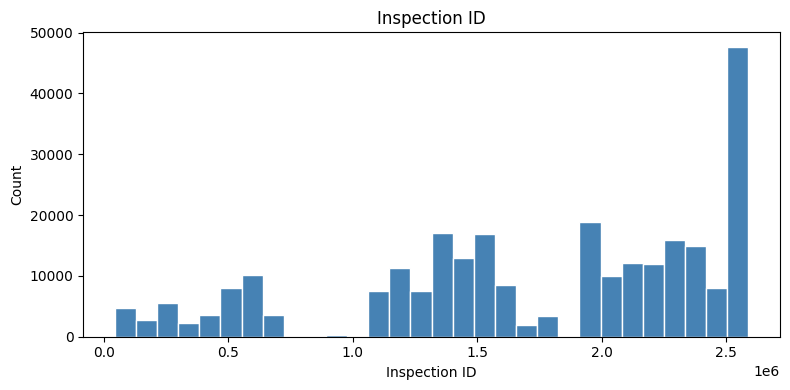

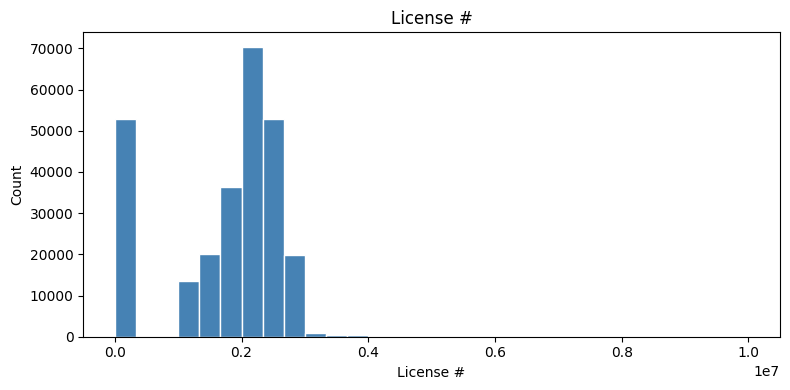

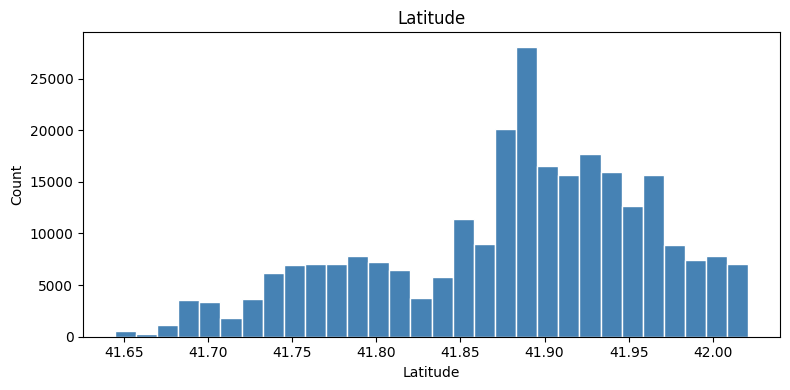

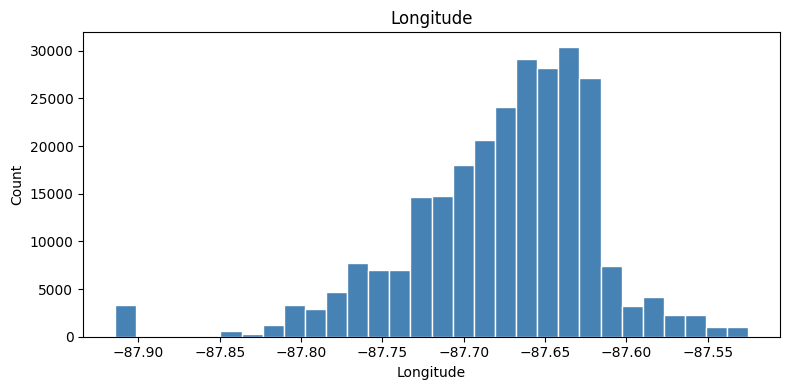

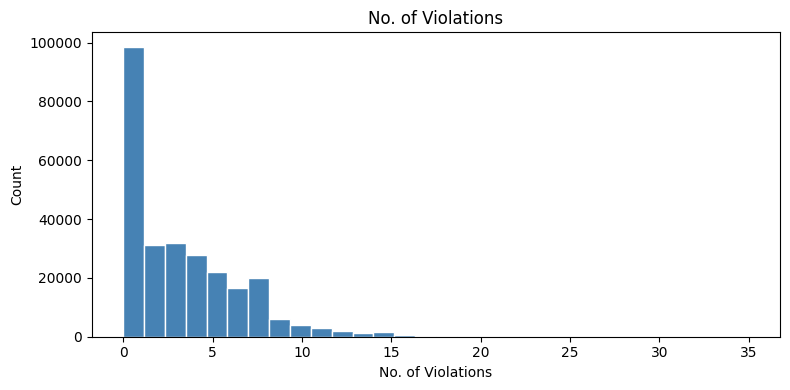

,column,min,max,mean,median,variance,Q1,Q2,Q3
0,Inspection ID,44247.000000,2.589430e+06,1.729715e+06,1.950830e+06,5.175845e+11,1.307352e+06,1.950830e+06,2.356946e+06
1,License #,0.000000,9.999999e+06,1.721737e+06,2.048784e+06,8.591924e+11,1.336815e+06,2.048784e+06,2.369039e+06
2,Latitude,41.644670,4.202106e+01,4.188070e+01,4.189177e+01,6.600000e-03,4.183182e+01,4.189177e+01,4.193979e+01
3,Longitude,-87.914428,-8.752509e+01,-8.767640e+01,-8.766642e+01,3.400000e-03,-8.770746e+01,-8.766642e+01,-8.763494e+01
4,No. of Violations,0.000000,3.500000e+01,3.282900e+00,3.000000e+00,1.132900e+01,0.000000e+00,3.000000e+00,5.000000e+00





------ 6. CATEGORICAL VALUE COUNTS (TOP 20) ------


,count,freq
Facility Type,,
Restaurant,179811,0.6721
Grocery Store,33299,0.1245
School,16882,0.0631
Children's Services Facility,5714,0.0214
NaN,5115,0.0191
Bakery,3848,0.0144
Daycare Above and Under 2 Years,3559,0.0133
Daycare (2 - 6 Years),3128,0.0117
Long Term Care,1961,0.0073


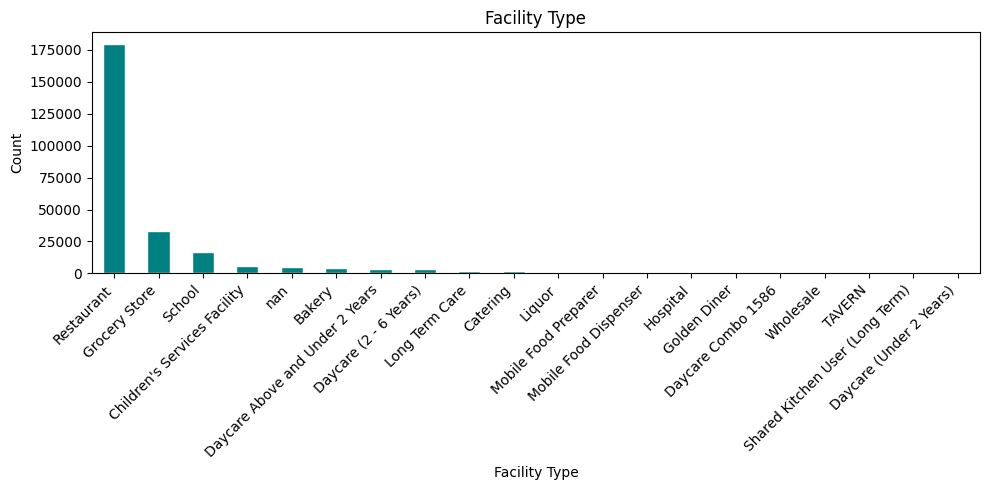

,count,freq
Risk,,
Risk 1 (High),196048,0.7328
Risk 2 (Medium),49560,0.1852
Risk 3 (Low),21790,0.0814
NaN,81,0.0003
All,52,0.0002


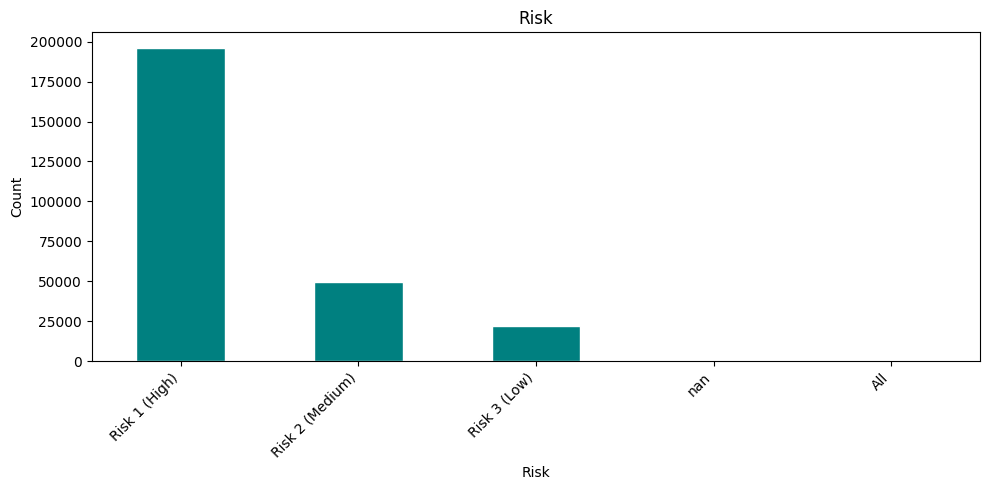

,count,freq
City,,
CHICAGO,266472,0.9960
Chicago,415,0.0016
NaN,161,0.0006
chicago,140,0.0005
CCHICAGO,55,0.0002
SCHAUMBURG,28,0.0001
CHicago,20,0.0001
EVANSTON,18,0.0001
MAYWOOD,15,0.0001


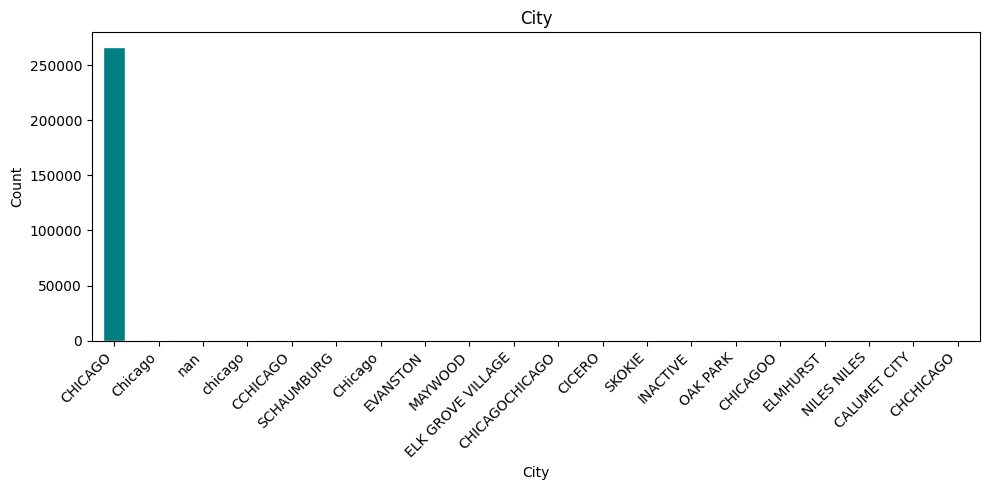

,count,freq
State,,
IL,267461,0.9997
NaN,59,0.0002
IN,7,0.0000
CA,2,0.0000
WI,1,0.0000
NY,1,0.0000


,count,freq
Inspection Type,,
Canvass,139061,0.5198
License,35707,0.1335
Canvass Re-Inspection,29456,0.1101
Complaint,25349,0.0948
License Re-Inspection,11458,0.0428
Complaint Re-Inspection,10615,0.0397
Short Form Complaint,8311,0.0311
Non-Inspection,2823,0.0106
Suspected Food Poisoning,971,0.0036


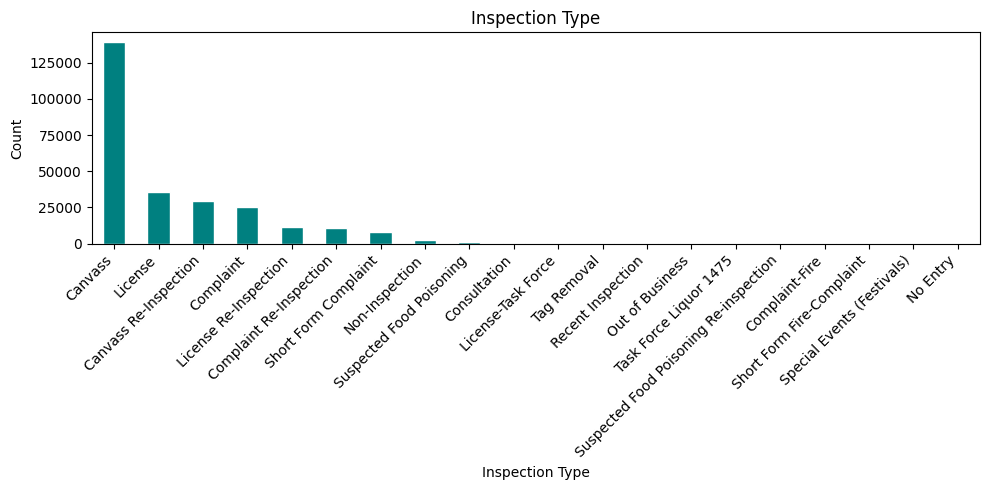

,count,freq
Results,,
Pass,137733,0.5148
Fail,52265,0.1954
Pass w/ Conditions,40750,0.1523
Out of Business,22616,0.0845
No Entry,10689,0.0400
Not Ready,3392,0.0127
Business Not Located,86,0.0003


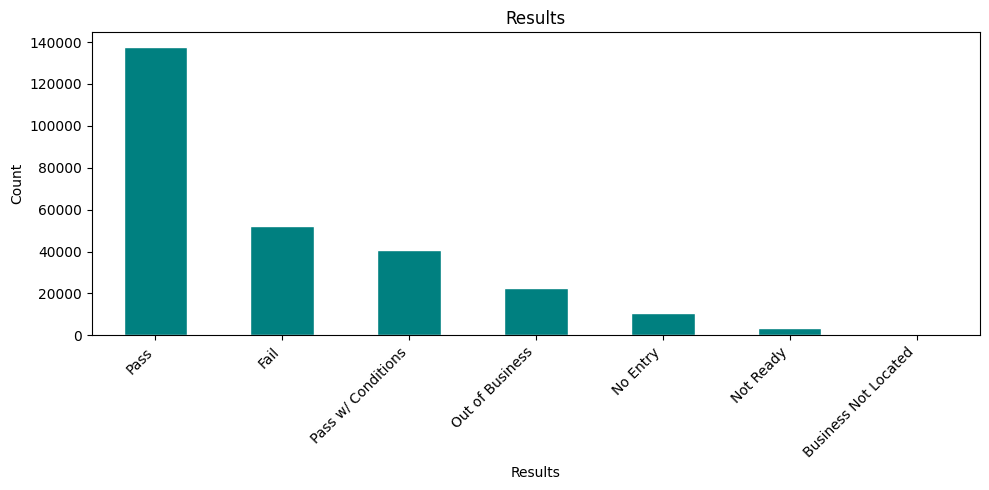




------ 7. VIOLATION CODE FREQUENCY ------


,count
0,
1,4094
2,13572
3,26060
4,530
5,18144
...,...
61,1397
62,141
63,35


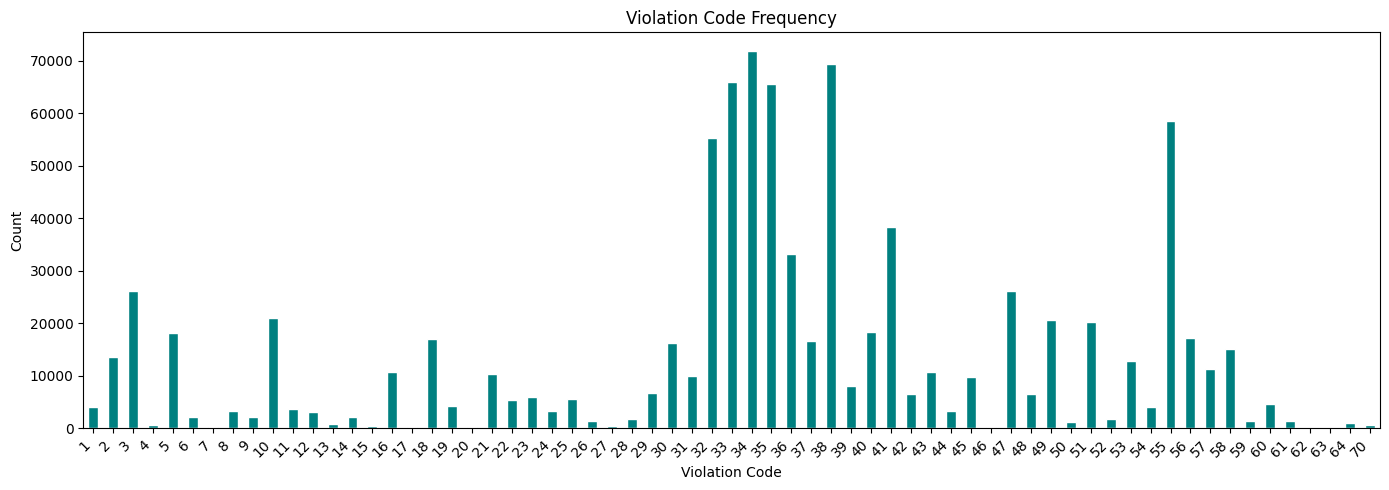




------ 8. TYPE & PATTERN ANALYSIS ------


,count
Zip,
0,49
5,267482


5-char: 0.9998  |  digits-only: 0.9998
States: ['CA', 'IL', 'IN', 'NY', 'WI']  |  IL fraction: 0.9997


,count
City,
CHICAGO,266472
Chicago,415
NaN,161
chicago,140
CCHICAGO,55
SCHAUMBURG,28
CHicago,20
EVANSTON,18
MAYWOOD,15


CHICAGO exact: 266472  |  Chicago title: 415  |  any variant: 267047
Location pattern match: 0.9965



------ 9. VALIDITY PROFILE ------


...

,proportion
Facility Type,
Long Term Care,0.007473
Catering,0.006326
Liquor,0.004329
Mobile Food Preparer,0.003578
Mobile Food Dispenser,0.003548
...,...
NON-FOR PROFIT BASEMENT KIT,0.000004
FROZEN DESSERTS DISPENSER -NON MOTORIZED,0.000004
drug treatment facility,0.000004


,proportion
Inspection Type,
Suspected Food Poisoning,0.003629
Consultation,0.002531
License-Task Force,0.002258
Tag Removal,0.002254
Recent Inspection,0.001727
...,...
POSSIBLE FBI,0.000004
TASK FORCE NOT READY,0.000004
TASK FORCE LIQUOR (1481),0.000004


,proportion
Results,
Business Not Located,0.000321





------ 12. BENFORD'S LAW -- LICENSE # AND INSPECTION ID ------


,digit,count,frequency,benford_expected
0,1,78384,0.2938,0.3010
1,2,157663,0.5909,0.1761
2,3,10581,0.0397,0.1249
3,4,6227,0.0233,0.0969
4,5,3854,0.0144,0.0792
5,6,4024,0.0151,0.0669
6,7,3076,0.0115,0.0580
7,8,2356,0.0088,0.0512
8,9,658,0.0025,0.0458


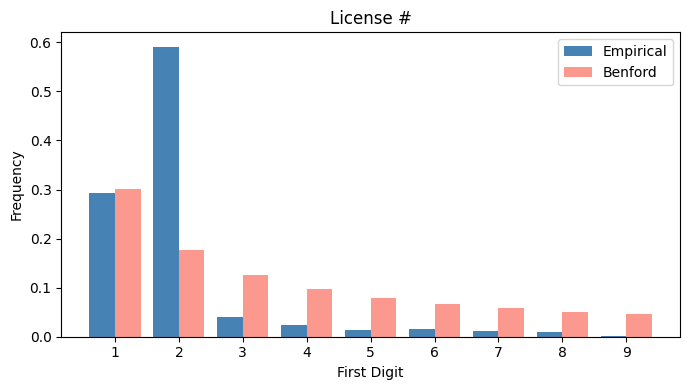

,digit,count,frequency,benford_expected
0,1,110630,0.4135,0.3010
1,2,125580,0.4694,0.1761
2,3,2532,0.0095,0.1249
3,4,5080,0.0190,0.0969
4,5,13695,0.0512,0.0792
5,6,7989,0.0299,0.0669
6,7,724,0.0027,0.0580
7,8,739,0.0028,0.0512
8,9,562,0.0021,0.0458


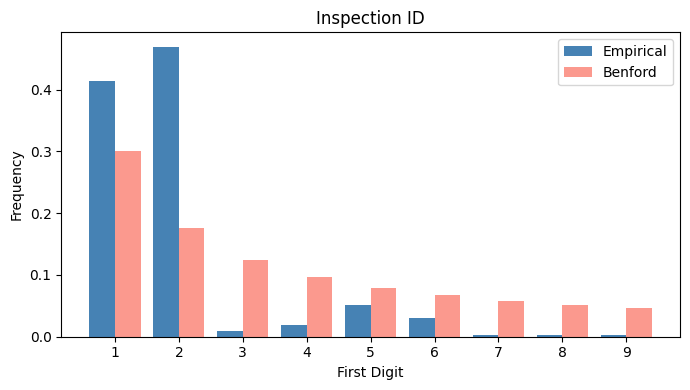

,Inspection ID,DBA Name,AKA Name,License #,Facility Type,Risk,Address,City,State,Zip,Inspection Date,Inspection Type,Results,Violations,Latitude,Longitude,Location,inspection_date_parsed,No. of Violations
0,2589375,PERFECT BEGINNINGS CHILD DEVELOPMENT CENTER,PERFECT BEGINNINGS CHILD DEVELOPMENT CENTER,2385784.0,Daycare Above and Under 2 Years,Risk 1 (High),1500 W 119TH ST,CHICAGO,IL,60643,02/08/2024,License,Pass,"51. PLUMBING INSTALLED; PROPER BACKFLOW DEVICES - Comments: OBSERVED MISSING DRAIN STOPPERS FOR THE 3-COMPARTMENT SINK. INSTRUCTED TO PROVIDE DRAIN STOPPERS FOR ALL THREE BASINS OF 3-COMPARTMENT SINK AND MAINTAIN. | 55. PHYSICAL FACILITIES INSTALLED, MAINTAINED & CLEAN - Comments: OBSERVED SMALL GREASE SPILL BENEATH 3-COMPARTMENT SINK IN CORNER. INSTRUCTED TO CLEAN AND SANITIZE AND ARRANGE AREA TO ALLOW FOR FREQUENT CLEANING AND MAINTAIN. | 55. PHYSICAL FACILITIES INSTALLED, MAINTAINED & CLEAN - Comments: OBSERVED BASE COVING MISSING ON EXTERIOR WALL IN KITCHEN AREA. INSTRUCTED TO PROVIDE BASE COVING FOR ALL WALLS IN AREAS SUBJECT TO SPLASHING AND/OR MOISTURE AND MAINTAIN. | 56. ADEQUATE VENTILATION & LIGHTING; DESIGNATED AREAS USED - Comments: OBSERVED VENTILATION HOOD FILTER HEAVILY SOILED WITH CAKED GREASE. INSTRUCTED TO CLEAN OR REPLACE FILTER AND MAINTAIN.",41.677685,-87.659020,"(41.677685065833224, -87.65901954921286)",2024-02-08,4
1,2589377,BIG BOSS SPICY FRIED CHICKEN,BIG BOSS SPICY FRIED CHICKEN,2807954.0,Restaurant,Risk 1 (High),2520 S HALSTED ST,CHICAGO,IL,60608,02/08/2024,Canvass,Fail,"23. PROPER DATE MARKING AND DISPOSITION - Comments: 3-501.17 OBSERVED READY-TO-EAT TCS FOODS (MACARONI SALAD) IN A REFRIGERATOR WITHOUT LABELS CONTAINING THE PRODUCT DISCARD DATE. INSTRUCTED TO PROVIDE LABELS WITH PRODUCT DISCARD DATES FOR ALL TCS RTE FOODS THAT ARE HELD FOR MORE THAN 24 HOURS IN A REFRIGERATOR. PRIORITY FOUNDATION. CITATION ISSUED 7-38-005. | 37. FOOD PROPERLY LABELED; ORIGINAL CONTAINER - Comments: 3-302.12 OBSERVED SPICES/DRY STORAGE (RICE) OUT OF THE ORIGINAL PACKAGING IN CONTAINERS WITHOUT LABELS. INSTRUCTED TO LABEL ALL SPICE/DRY STORAGE CONTAINERS. | 38. INSECTS, RODENTS, & ANIMALS NOT PRESENT - Comments: 6-501.111 OBSERVED EVIDENCE OF RODENT ACTIVITY ON SITE. OBSERVED ABOUT 200 RODENT DROPPINGS LOCATED BEHIND THE COOKING EQUIPMENT AND UNDER ALL DRY STORAGE SHELVES. OBSERVED ABOUT 150 RODENT DROPPINGS IN THE HOT WATER HEATER ROOM, BEHIND REACH IN FREEZERS, AND REFRIGERATION UNITS. OBSERVED ABOUT 100 RODENT DROPPINGS INSIDE OF ALL FRYERS. INSTRUCTED TO ELIMINATE RODENT ACTIVITY, CLEAN AND SANITIZE AFFECTED AREAS AND RECOMMENDED CONTACTING PEST CONTROL FOR A SERVICE. PRIORITY FOUNDATION. CITATION ISSUED 7-38-020(A). | 38. INSECTS, RODENTS, & ANIMALS NOT PRESENT - Comments: 6-202.15 OBSERVED FRONT ENTRANCE DOOR WITH A 1/4 INCH GAP AT THE BOTTOM. INSTRUCTED TO MAKE SAID FRONT ENTRANCE DOOR RODENT PROOFED AND TIGHT FITTING. | 45. SINGLE-USE/SINGLE-SERVICE ARTICLES: PROPERLY STORED & USED - Comments: 4-502.13 OBSERVED SINGLE-USE CONTAINERS (SOY SAUCE CONTAINERS) AND SINGLE-USE GROCERY BAGS BEING USED FOR FOOD STORAGE IN THE REACH-IN FREEZERS AND THE WALK-IN COOLER. INSTRUCTED TO ONLY USE FOOD-GRADE STORAGE CONTAINERS AND FOOD-GRADE STORAGE BAGS FOR ALL FOOD STORAGE. | 49. NON-FOOD/FOOD CONTACT SURFACES CLEAN - Comments: 4-601.11(C) OBSERVED ALL NON-FOOD CONTACT SURFACES WITH EXCESSIVE ACCUMULATED FOOD DEBRIS LOCATED ON THE HANDLES OF ALL REFRIGERATION UNITS AND PREP COOLERS, INTERIOR OF ALL REFRIGERATION UNITS AND PREP COOLERS, CUTTING BOARDS WITH DARK GROOVES USED FOR SALAD PREPARATION, INTERIOR OF ALL FRYERS WITH EXCESSIVE ACCUMULATED FOOD AND GREASE DEBRIS. INSTRUCTED TO CLEAN AND SANITIZE ALL. | 53. TOILET FACILITIES: PROPERLY CONSTRUCTED, SUPPLIED, & CLEANED - Comments: 5-501.17 OBSERVED NO COVERED RECEPTACLES INSIDE REAR EMPLOYEE'S TOILET ROOMS. INSTRUCTED TO PROVIDE. | 54. GARBAGE & REFUSE PROPERLY DISPOSED; FACILITIES MAINTAINED - Comments: 5-501.113 OBSERVED FACILITY USING SINGLE-USE FOOD STORAGE C

In [9]:
run_single_column_profiling("Food_Inspections_20240215.csv")

In [10]:
"""
Another way to run association rule mining:

cols_to_mine = ['Facility Type', 'Risk', 'Results']
arm_rules = run_association_rule_mining(
    csv_path="Food_Inspections_20240215.csv",
    columns_to_analyze=cols_to_mine,
    min_support=0.03
)
"""

arm_rules = run_association_rule_mining("Food_Inspections_20240215.csv")


TASK: ASSOCIATION RULE MINING
------ 1. LOAD DATA ------



------ 2. SELECTING RELEVANT CATEGORICAL COLUMNS ------



------ 3. ONE-HOT ENCODING THE DATA ------



------ 4. RUNNING APRIORI ALGORITHM (min_support=0.05) ------



------ 5. GENERATE ASSOCIATION RULES ------

Successfully generated 32 rules.

------ Top 10 Association Rules ------


,antecedents,consequents,support,confidence,lift
0,(Inspection Type_Canvass),(Results_Out of Business),0.069281,0.134927,1.914369
1,(Results_Out of Business),(Inspection Type_Canvass),0.069281,0.982967,1.914369
2,"(Inspection Type_Canvass Re-Inspection, Facility Type_Restaurant)","(Results_Pass, Risk_Risk 1 (High))",0.052436,0.687503,1.743482
3,"(Results_Pass, Risk_Risk 1 (High))","(Inspection Type_Canvass Re-Inspection, Facility Type_Restaurant)",0.052436,0.132976,1.743482
4,(Inspection Type_Canvass Re-Inspection),"(Facility Type_Restaurant, Results_Pass, Risk_Risk 1 (High))",0.052436,0.467389,1.664103
5,"(Facility Type_Restaurant, Results_Pass, Risk_Risk 1 (High))",(Inspection Type_Canvass Re-Inspection),0.052436,0.186694,1.664103
6,"(Inspection Type_Canvass Re-Inspection, Risk_Risk 1 (High))","(Facility Type_Restaurant, Results_Pass)",0.052436,0.568483,1.632139
7,"(Facility Type_Restaurant, Results_Pass)","(Inspection Type_Canvass Re-Inspection, Risk_Risk 1 (High))",0.052436,0.150546,1.632139
8,(Inspection Type_Canvass Re-Inspection),"(Results_Pass, Risk_Risk 1 (High))",0.071838,0.640329,1.623850
9,"(Results_Pass, Risk_Risk 1 (High))",(Inspection Type_Canvass Re-Inspection),0.071838,0.182178,1.623850


In [11]:
fds_df = run_functional_dependencies("Food_Inspections_20240215.csv")


TASK: FUNCTIONAL DEPENDENCIES
------ 1. LOAD DATA ------
  Full dataset : 259,025 rows, 15 columns
  Columns      : ['Inspection ID', 'DBA Name', 'AKA Name', 'License #', 'Facility Type', 'Risk', 'Address', 'City', 'State', 'Zip', 'Inspection Date', 'Inspection Type', 'Results', 'Latitude', 'Longitude']




------ 2. FIND FDs ------
  Sample size  : 150,000 rows

Unique value counts per column:
  Inspection ID                           : 150,000
  License #                               : 34,331
  DBA Name                                : 25,609
  AKA Name                                : 24,804
  Address                                 : 17,261
  Latitude                                : 16,408
  Longitude                               : 16,408
  Inspection Date                         : 3,533
  Facility Type                           : 434
  Inspection Type                         : 68
  Zip                                     : 64
  City                                    : 17
  Re

In [12]:
run_functional_dependencies_no_sampling("Food_Inspections_20240215.csv")


TASK: FUNCTIONAL DEPENDENCIES (NO SAMPLING)
------ 1. LOAD DATA ------
  Full dataset : 259,025 rows, 15 columns
  Columns      : ['Inspection ID', 'DBA Name', 'AKA Name', 'License #', 'Facility Type', 'Risk', 'Address', 'City', 'State', 'Zip', 'Inspection Date', 'Inspection Type', 'Results', 'Latitude', 'Longitude']




------ 2. FIND FDs ------
Unique value counts per column:
  Inspection ID                           : 259,025
  License #                               : 38,936
  DBA Name                                : 27,642
  AKA Name                                : 26,844
  Address                                 : 18,103
  Latitude                                : 17,128
  Longitude                               : 17,128
  Inspection Date                         : 3,559
  Facility Type                           : 483
  Inspection Type                         : 100
  Zip                                     : 64
  City                                    : 18
  Results           

,lhs,rhs,lhs_size
0,[Inspection ID],DBA Name,1
1,[Inspection ID],AKA Name,1
2,[Inspection ID],License #,1
3,[Inspection ID],Facility Type,1
4,[Inspection ID],Risk,1
5,[Inspection ID],Address,1
6,[Inspection ID],City,1
7,[Inspection ID],State,1
8,[Inspection ID],Zip,1
9,[Inspection ID],Inspection Date,1



TASK: INCLUSION DEPENDENCIES
✅ Dataset loaded: 267,531 rows × 17 columns

📋 Columns (17):
   1. Inspection ID
   2. DBA Name
   3. AKA Name
   4. License #
   5. Facility Type
   6. Risk
   7. Address
   8. City
   9. State
  10. Zip
  11. Inspection Date
  12. Inspection Type
  13. Results
  14. Violations
  15. Latitude
  16. Longitude
  17. Location
── Step 1: Risk ─────────────────────────────────────────
  Valid Risk rows   : 267,398
  Dropped (invalid) : 133
  Invalid values seen:
Risk
NAN    81
ALL    52

── Step 2: Address ──────────────────────────────────────
  Valid addresses   : 249,266
  Invalid addresses : 18,132 (flagged, not dropped)

── Step 3: Location / State / City / Zip ────────────────

  [3a] Fixing State/City from Location coordinates...
  State corrected to IL      : 59
  City corrected to CHICAGO  : 270
  Null Locations filled      : 920  (avg: 41.880734, -87.676429)

  [3b] Dropping non-IL rows...
  Dropped (non-IL) : 11

  [3c] Cleaning City...
  Non-Chicag

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/8 [00:00<?, ?it/s]


  ⚠️  229 low-confidence matches — review:
                              Original                                                       Matched to  Score Confidence
                        Shared Kitchen                                                          Caterer 0.4994        low
                      employee kitchen                                                          Caterer 0.4968        low
                       CHURCH/DAY CARE Day Care Center (combo, for ages less than 2 and 2 - 6 combined) 0.4965        low
                             CAFETERIA                                                           School 0.4963        low
                             cafeteria                                                           School 0.4963        low
                             Cafeteria                                                           School 0.4963        low
                          smoothie bar                                                      Coffee Sho

,Column,Type,Unique,Uniqueness,IND useful
0,Inspection ID,id / free_text,267138,100.00%,False
1,DBA Name,free_text,31990,11.98%,True
2,AKA Name,free_text,30463,11.51%,True
3,License #,numeric_code,44315,16.59%,False
4,Facility Type,semi-categorical,23,0.01%,True
5,Risk,categorical,3,0.00%,True
6,Address,free_text,19321,7.23%,True
7,City,categorical,1,0.00%,True
8,State,categorical,1,0.00%,True
9,Zip,numeric_code,62,0.02%,False



  STEP 2 — IND Computation (meaningful columns only)


Computing INDs: 196pair [00:00, 11371.71pair/s]          



  Total pairs evaluated : 182
  Exact   (= 1.00)      : 0
  Strong  (≥ 0.90)      : 0
  Partial (0.50–0.90)   : 3
  Weak    (< 0.50)      : 179

  STEP 3 — Key Findings (coverage ≥ 0.04)
  [Partial]  AKA Name                       ⊆  DBA Name
             coverage=0.8016  matched=24,418  |████████████████████████      |
             Unique only in A  : 6,045
             Shared (A ∩ B)    : 24,418
             Unique only in B  : 7,572
             Sample shared     : ['#1 CHOP SUEY', '#1 CHOP SUEY RESTAURANT', '#1 DELI', '#1 DELI, INC', '#1 MARKET INC.']
             Null rate A/B     : 0.9% / 0.0%
             Null-aware cov    : 0.8011

  [Partial]  DBA Name                       ⊆  AKA Name
             coverage=0.7633  matched=24,418  |██████████████████████        |
             Unique only in A  : 7,572
             Shared (A ∩ B)    : 24,418
             Unique only in B  : 6,045
             Sample shared     : ['#1 CHOP SUEY', '#1 CHOP SUEY RESTAURANT', '#1 DELI', '#1 DELI, 

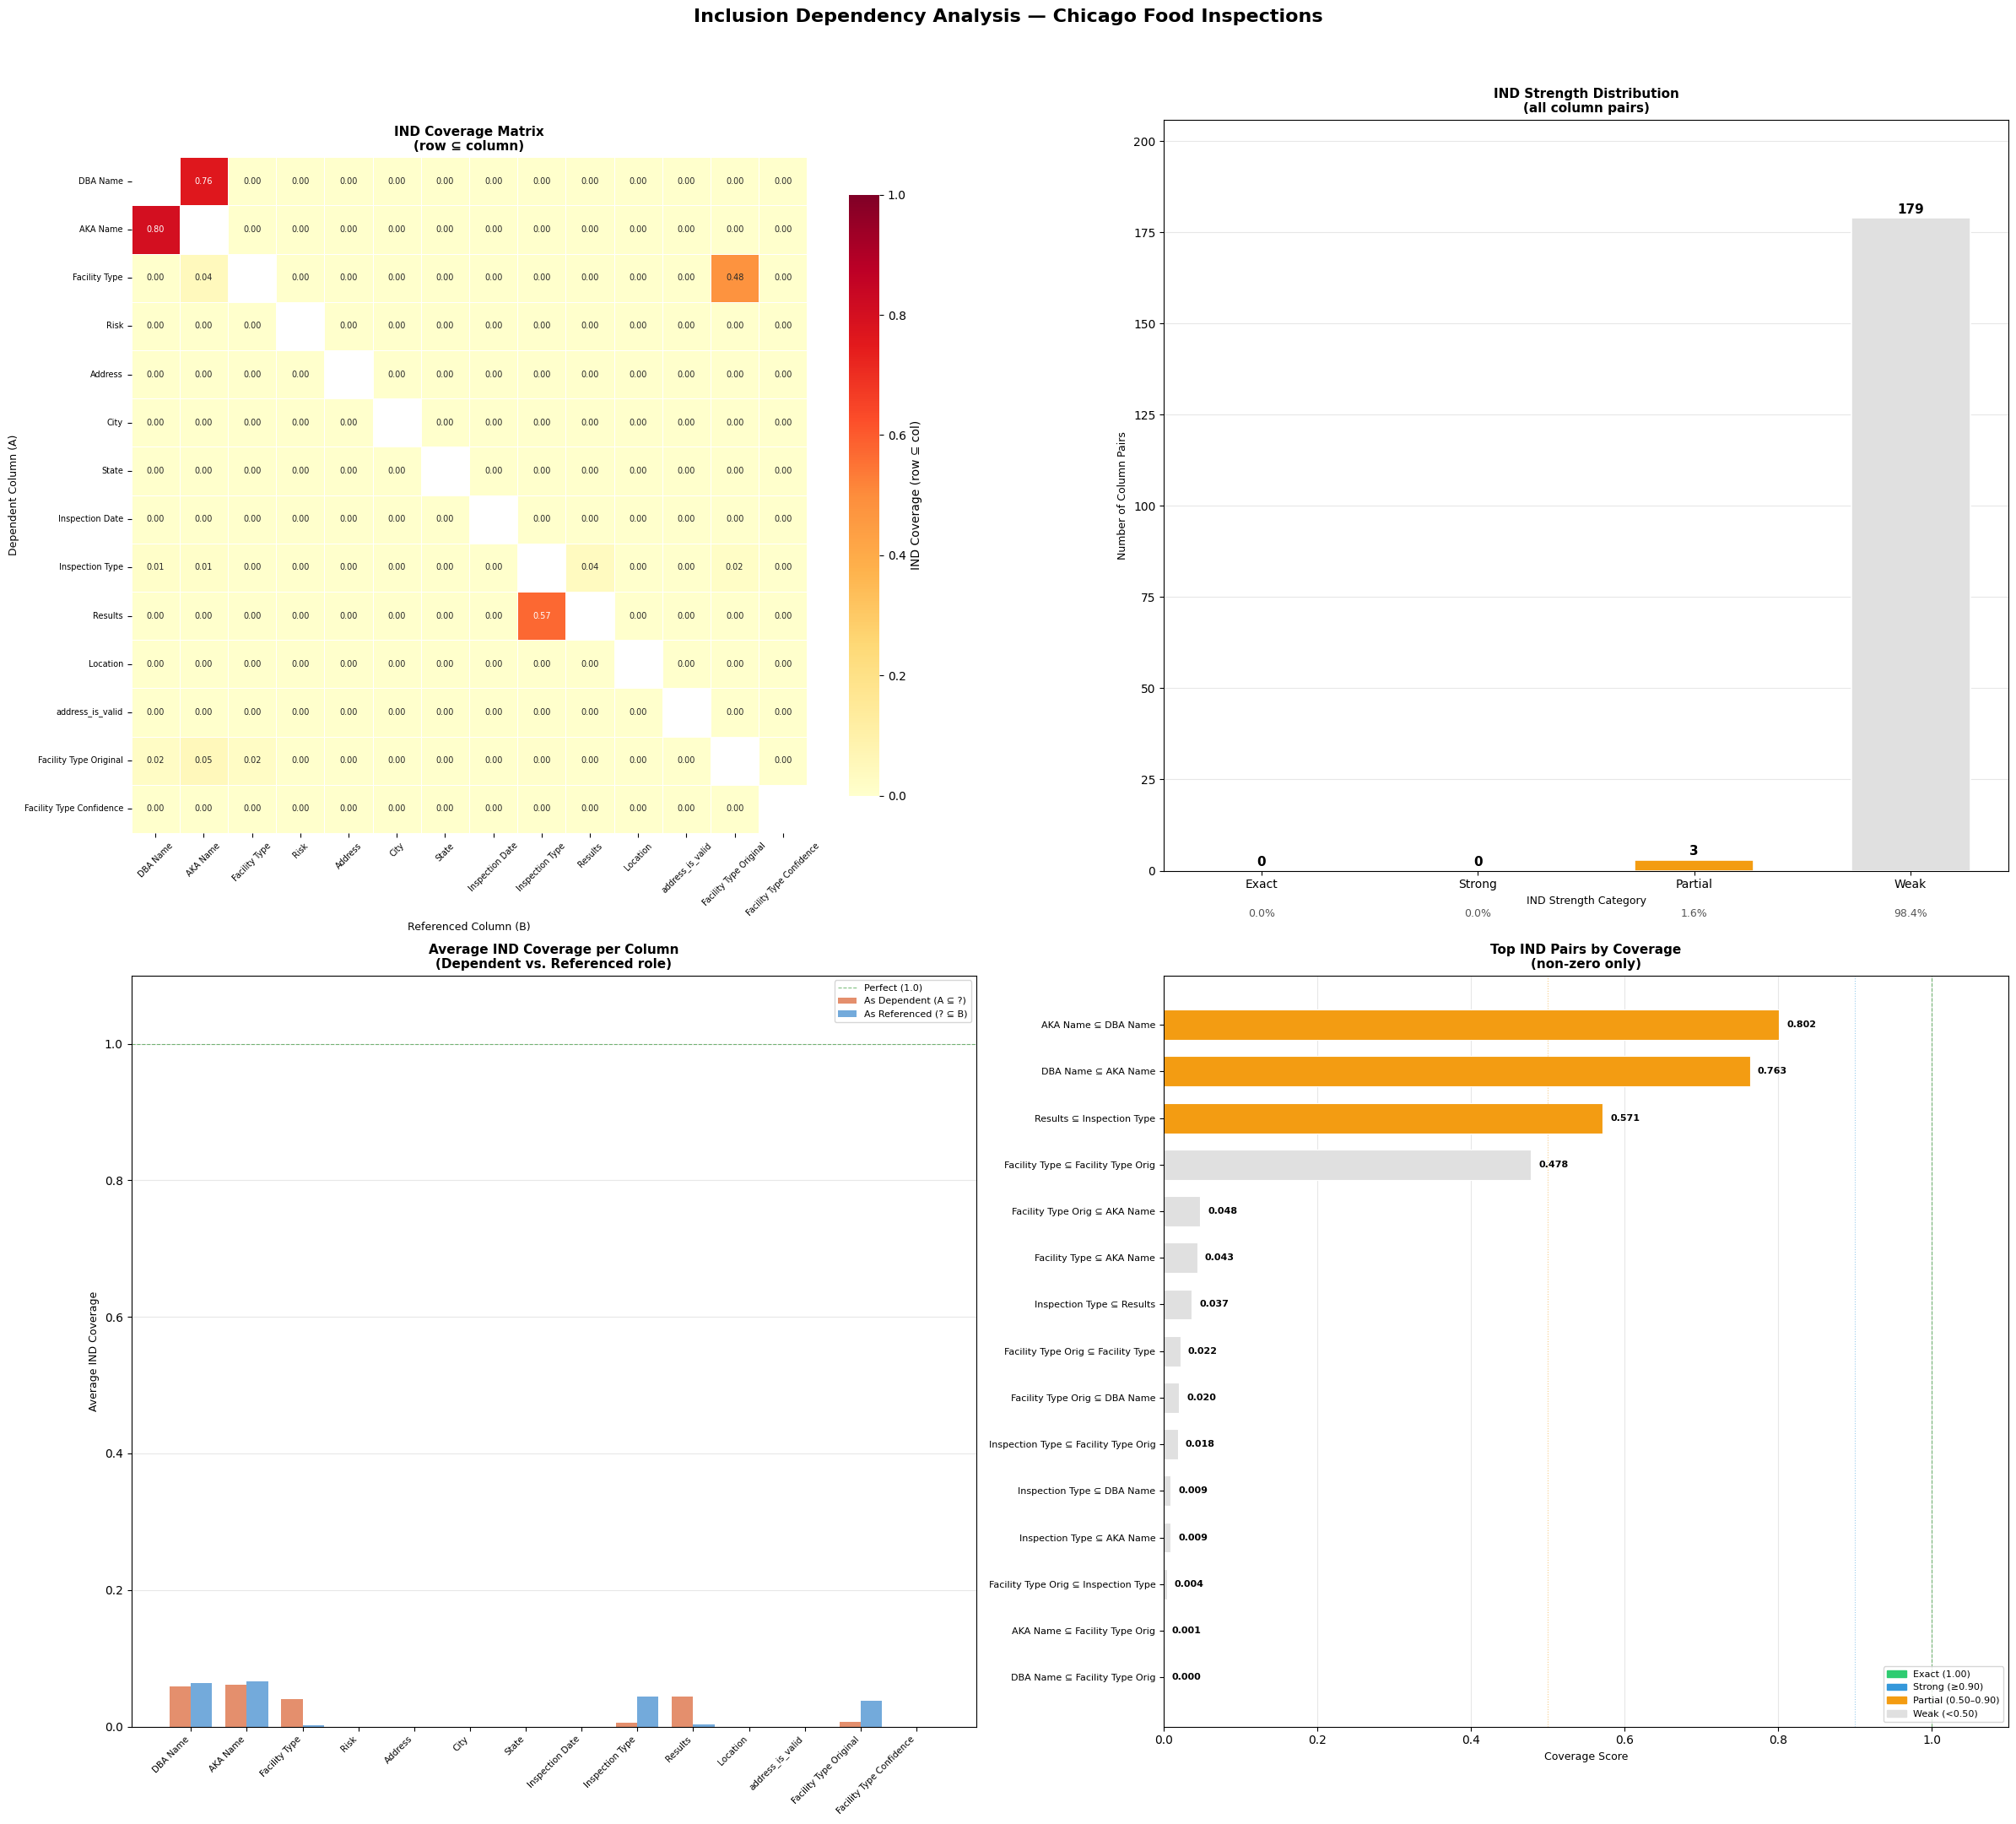

💾 Saved: ind_full_analysis.png

  FINAL SUMMARY

  Dataset           : 267,138 rows × 21 columns
  Columns analysed  : 14 (after excluding ids/coords/numeric codes)
  Columns excluded  : 7
  Pairs evaluated   : 182

  IND Breakdown:
    Exact   (A fully contained in B) : 0
    Strong  (≥90% overlap)           : 0
    Partial (50–90% overlap)          : 3
    Weak    (<50% overlap)            : 179

  Symmetric INDs found              : 0

  Interpretation:
  → The dataset is well-normalised. Columns are largely
    independent, confirming no accidental redundancy.
  → 3 partial IND(s) detected — review the key
    findings above for schema inconsistencies or column overlap.


In [4]:
ind_results, type_df = run_inclusion_dependencies("Food_Inspections_20240215.csv", min_coverage=0.0)

# Handle Data Quality Problem

Use the actual outputs from the two tasks above:
- **`arm_rules`** from `run_association_rule_mining()`
- **`fds_df`** from `run_functional_dependencies()` or `run_functional_dependencies_no_sampling()`

Two quality checks are applied:
1. **ARM anomaly detection** — flag rows with unexpected attribute combinations
2. **FD violation repair** — detect & fix inconsistencies using majority-vote

## Helpers

In [13]:
def _load(csv_path):
    df = pd.read_csv(csv_path, encoding="utf-8", dtype=str)
    df.columns = [c.strip() for c in df.columns]
    for col in df.columns:
        df[col] = df[col].str.strip()
    return df

def _parse_lhs(lhs_val):
    """Handle lhs stored as a Python list OR its string repr."""
    if isinstance(lhs_val, list):
        return lhs_val
    try:
        return _ast.literal_eval(str(lhs_val))
    except Exception:
        return [str(lhs_val)]

## ARM-Based Anomaly Detection

In [14]:
def arm_anomaly_detection(
    df,
    rules,
    columns_to_analyze=None,
    confidence_threshold=0.80,
    lift_threshold=1.5,
):
    """
    Flag rows that violate strong association rules.

    Parameters
    ----------
    df                   : DataFrame
    rules                : output of run_association_rule_mining()
    columns_to_analyze   : columns used when the rules were mined
                           default: ['Facility Type','Risk','Inspection Type','Results']
    confidence_threshold : minimum rule confidence  (default 0.80)
    lift_threshold       : minimum rule lift        (default 1.5)

    Returns
    -------
    df_flagged  : df + arm_anomaly_flag, arm_violated_rules columns
    arm_summary : DataFrame — one row per violated rule with counts
    """
    print("\n" + "=" * 60)
    print("ARM-BASED ANOMALY DETECTION")
    print("=" * 60)

    if columns_to_analyze is None:
        columns_to_analyze = ["Facility Type", "Risk", "Inspection Type", "Results"]

    df_flagged = df.copy()
    df_flagged["arm_anomaly_flag"]   = False
    df_flagged["arm_violated_rules"] = ""

    # Filter for strong rules only
    strong = rules[
        (rules["confidence"] >= confidence_threshold) &
        (rules["lift"]       >= lift_threshold)
    ].copy()
    print(f"  Strong rules (conf>={confidence_threshold}, lift>={lift_threshold}): {len(strong)} / {len(rules)}")

    if strong.empty:
        print("  No strong rules found — try lowering the thresholds.")
        return df_flagged, pd.DataFrame()

    present = [c for c in columns_to_analyze if c in df.columns]
    df_enc  = pd.get_dummies(df[present].fillna("__MISSING__"), prefix=present).astype(bool)

    summary_rows = []
    for _, rule in strong.iterrows():
        ant_cols = [f for f in list(rule["antecedents"]) if f in df_enc.columns]
        con_cols = [f for f in list(rule["consequents"]) if f in df_enc.columns]
        if not ant_cols or not con_cols:
            continue

        violated = df_enc[ant_cols].all(axis=1) & ~df_enc[con_cols].all(axis=1)
        n = violated.sum()

        rule_str = (
            f"{set(rule['antecedents'])} -> {set(rule['consequents'])} "
            f"[conf={rule['confidence']:.2f}, lift={rule['lift']:.2f}]"
        )
        if n > 0:
            df_flagged.loc[violated, "arm_anomaly_flag"] = True
            df_flagged.loc[violated, "arm_violated_rules"] += (
                df_flagged.loc[violated, "arm_violated_rules"]
                .apply(lambda x: ("" if x == "" else " | ") + rule_str)
            )
            print(f"\n  Rule  : {rule_str}")
            print(f"  Rows  : {n:,}  ({n/len(df)*100:.2f}%)")

        summary_rows.append({
            "rule"        : rule_str,
            "confidence"  : round(rule["confidence"], 4),
            "lift"        : round(rule["lift"],       4),
            "n_violations": n,
            "pct"         : round(n / len(df) * 100, 2),
        })

    arm_summary = pd.DataFrame(summary_rows)
    total = df_flagged["arm_anomaly_flag"].sum()
    print(f"\n  -> Total ARM anomalies flagged: {total:,}  ({total/len(df)*100:.2f}%)")
    return df_flagged, arm_summary

## FD-Based Violation Repair

In [15]:
def fd_violation_repair(df, fds_df, strategy="majority_vote"):
    """
    Detect and repair Functional Dependency violations.

    Only the actual minority (wrong) rows are flagged — not the whole group.
    Ties are detected and skipped to avoid replacing correct values.

    Parameters
    ----------
    df       : DataFrame
    fds_df   : output of run_functional_dependencies() — columns: lhs, rhs, lhs_size
    strategy : 'majority_vote'  or  'flag_only'

    Returns
    -------
    df_fixed  : repaired DataFrame + fd_violation_flag, fd_fixed_columns
    fd_report : DataFrame — one row per minority-row violation
    """
    print("\n" + "=" * 60)
    print("FD-BASED VIOLATION REPAIR")
    print("=" * 60)

    df_fixed = df.copy()
    df_fixed["fd_violation_flag"] = False
    df_fixed["fd_fixed_columns"]  = ""
    report_rows = []

    for _, fd_row in fds_df.iterrows():
        lhs = _parse_lhs(fd_row["lhs"])
        rhs = str(fd_row["rhs"])

        missing = [c for c in lhs + [rhs] if c not in df_fixed.columns]
        if missing:
            continue

        lhs_str = " + ".join(lhs)

        # ── Build majority/count/total tables per LHS group ──────────────────
        base = df_fixed.dropna(subset=lhs + [rhs])

        stats = (
            base.groupby(lhs)[rhs]
            .agg(
                _majority    = lambda x: x.value_counts().index[0],
                _maj_count   = lambda x: x.value_counts().iloc[0],
                _total_count = "count",
            )
            .reset_index()
        )
        # rename to avoid column clashes when merging back
        stats = stats.rename(columns={
            "_majority"   : "__majority__",
            "_maj_count"  : "__maj_cnt__",
            "_total_count": "__tot_cnt__",
        })

        # ── Merge stats back to every row (vectorised — no apply) ────────────
        tmp = df_fixed.merge(stats, on=lhs, how="left")

        majority_per_row      = tmp["__majority__"].values
        majority_count_per_row = tmp["__maj_cnt__"].values
        total_count_per_row    = tmp["__tot_cnt__"].values

        # ── Identify groups with > 1 distinct RHS value ──────────────────────
        group_nunique = df_fixed.groupby(lhs)[rhs].transform("nunique")
        in_violated_group = (group_nunique > 1).values

        # Flag ONLY the minority rows (value ≠ group majority)
        rhs_values = df_fixed[rhs].values
        violated_mask = (
            in_violated_group &
            (rhs_values != majority_per_row) &
            (majority_per_row != None)
        )
        # Handle NaN majority (group entirely null)
        maj_is_nan = pd.isna(majority_per_row)
        violated_mask = violated_mask & ~maj_is_nan

        n_viol = violated_mask.sum()
        if n_viol == 0:
            continue

        n_groups = df_fixed.loc[in_violated_group].groupby(lhs).ngroups
        print(f"\n  FD   : [{lhs_str}] -> '{rhs}'")
        print(f"  Rows : {n_viol:,} minority rows  |  {n_groups:,} violating group(s)")

        df_fixed.loc[violated_mask, "fd_violation_flag"] = True
        df_fixed.loc[violated_mask, "fd_fixed_columns"] += (
            df_fixed.loc[violated_mask, "fd_fixed_columns"]
            .apply(lambda x: ("" if x == "" else ", ") + f"{lhs_str}->{rhs}")
        )

        # Report with correct majority_value + tie detection
        for lhs_key, grp in df_fixed.loc[violated_mask].groupby(lhs):
            lookup_key = lhs_key[0] if (isinstance(lhs_key, tuple) and len(lhs) == 1) else lhs_key

            subset = stats[stats[lhs].eq(
                pd.Series(dict(zip(lhs, [lookup_key] if len(lhs)==1 else lookup_key)))
            ).all(axis=1)]

            if not subset.empty:
                maj     = subset["__majority__"].iloc[0]
                maj_cnt = subset["__maj_cnt__"].iloc[0]
                tot_cnt = subset["__tot_cnt__"].iloc[0]
            else:
                maj, maj_cnt, tot_cnt = None, 0, 0

            is_strict = bool(maj_cnt > tot_cnt / 2) if tot_cnt > 0 else False
            report_rows.append({
                "fd"             : f"[{lhs_str}] -> '{rhs}'",
                "lhs_value"      : str(lhs_key),
                "rhs_bad_values" : str(grp[rhs].value_counts().to_dict()),
                "majority_value" : str(maj) if maj is not None else "?",
                "strict_majority": is_strict,
                "rows_flagged"   : len(grp),
                "will_repair"    : is_strict and strategy == "majority_vote",
            })

        # ── Repair ────────────────────────────────────────────────────────────
        if strategy == "majority_vote":
            old_vals = df_fixed[rhs].copy()

            # Skip repair when no strict majority (ties)
            strict_majority_mask = (majority_count_per_row > total_count_per_row / 2)
            can_repair = violated_mask & strict_majority_mask

            df_fixed.loc[can_repair, rhs] = pd.array(majority_per_row)[can_repair]

            n_changed = (old_vals != df_fixed[rhs]).sum()
            n_skipped = violated_mask.sum() - can_repair.sum()
            msg = f"  Fixed : {n_changed:,} values updated in '{rhs}'"
            if n_skipped:
                msg += f"  |  {n_skipped:,} skipped (tie — no strict majority)"
            print(msg)

    fd_report = pd.DataFrame(report_rows)
    total = df_fixed["fd_violation_flag"].sum()
    print(f"\n  -> Total FD minority-row violations: {total:,}  ({total/len(df)*100:.2f}%)")
    if not fd_report.empty:
        print("\n  FD Violation Report:")
        display(fd_report)
    return df_fixed, fd_report

## Combined Pipeline

Pass in the already-computed `arm_rules` and `fds_df` to avoid re-running the mining steps.

In [16]:
def run_data_quality_pipeline(
    csv_path,
    arm_rules=None,
    fds_df=None,
    arm_conf_threshold=0.80,
    arm_lift_threshold=1.5,
    fd_strategy="majority_vote",
    output_path="Food_Inspections_cleaned.csv"
):
    """
    Data quality pipeline: ARM anomaly detection + FD repair.
    """
    print("\n" + "=" * 60)
    print("DATA QUALITY PIPELINE")
    print("=" * 60)

    df = _load(csv_path)
    print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

    # ARM — Statistical Anomaly Detection
    if arm_rules is None:
        print("\nRunning ARM from scratch...")
        from mlxtend.frequent_patterns import apriori, association_rules as _arm
        ARM_COLS = ["Facility Type", "Risk", "Inspection Type", "Results"]
        df_enc    = pd.get_dummies(df[ARM_COLS].dropna(), prefix=ARM_COLS).astype(bool)
        arm_rules = _arm(apriori(df_enc, min_support=0.05, use_colnames=True),
                         metric="lift", min_threshold=1.2)
        arm_rules = arm_rules.sort_values("lift", ascending=False).reset_index(drop=True)
        print(f"  {len(arm_rules)} rules generated.")
    else:
        print("\nUsing provided ARM rules.")

    df_arm, arm_summary = arm_anomaly_detection(
        df, arm_rules,
        confidence_threshold=arm_conf_threshold,
        lift_threshold=arm_lift_threshold,
    )

    # FD — Consistency Error Repair
    if fds_df is None:
        print("\nNo FD results provided — skipping FD repair.")
        df_fd = df.copy()
        df_fd["fd_violation_flag"] = False
        df_fd["fd_fixed_columns"]  = ""
        fd_report = pd.DataFrame()
    else:
        print("\nUsing provided FD results.")
        df_fd, fd_report = fd_violation_repair(df.copy(), fds_df, strategy=fd_strategy)

    # Merge all flags
    print("\nMerging ARM and FD results...")
    df_clean = df_fd.copy()
    df_clean["arm_anomaly_flag"]   = df_arm["arm_anomaly_flag"].values
    df_clean["arm_violated_rules"] = df_arm["arm_violated_rules"].values
    df_clean["any_quality_issue"]  = (
        df_clean["arm_anomaly_flag"] | df_clean["fd_violation_flag"]
    )

    n     = len(df_clean)
    arm_n = int(df_clean["arm_anomaly_flag"].sum())
    fd_n  = int(df_clean["fd_violation_flag"].sum())
    any_n = int(df_clean["any_quality_issue"].sum())

    print("\n" + "=" * 60)
    print("QUALITY PIPELINE SUMMARY")
    print("=" * 60)
    print(f"  Total rows                     : {n:,}")
    print(f"  ARM anomalies flagged          : {arm_n:,}  ({arm_n/n*100:.2f}%)")
    print(f"  FD violations flagged/fixed    : {fd_n:,}  ({fd_n/n*100:.2f}%)")
    print(f"  Any quality issue (ARM or FD)  : {any_n:,}  ({any_n/n*100:.2f}%)")

    df_clean.to_csv(output_path, index=False)
    print(f"\n  Saved -> {output_path}")

    return df_clean, {
        "arm_summary": arm_summary,
        "fd_report"  : fd_report,
        "row_counts" : {
            "total": n, "arm_anomalies": arm_n,
            "fd_violations": fd_n, "any_issue": any_n
        },
    }

## Run

Pass the already-computed results from earlier cells into the pipeline
to avoid re-running ARM and FD discovery.

- `arm_rules` is the return value of `run_association_rule_mining()`
- `fds_df` is the return value of `run_functional_dependencies()`

In [17]:
CSV_PATH = "Food_Inspections_20240215.csv"

"""
# ── Option: compute everything from scratch ─────────────────────────────────────
arm_rules = run_association_rule_mining(CSV_PATH)
fds_df    = run_functional_dependencies(CSV_PATH)

df_clean, report = run_data_quality_pipeline(
    CSV_PATH,
    arm_rules = arm_rules,
    fds_df    = fds_df,
)
"""
df_clean, report = run_data_quality_pipeline(
      CSV_PATH,
      arm_rules          = arm_rules,   # from run_association_rule_mining()
      fds_df             = fds_df,      # from run_functional_dependencies()
      arm_conf_threshold = 0.80,
      arm_lift_threshold = 1.5,
      fd_strategy        = "majority_vote",
)


DATA QUALITY PIPELINE
Loaded: 267,531 rows x 17 columns

Using provided ARM rules.

ARM-BASED ANOMALY DETECTION
  Strong rules (conf>=0.8, lift>=1.5): 1 / 32

  Rule  : {'Results_Out of Business'} -> {'Inspection Type_Canvass'} [conf=0.98, lift=1.91]
  Rows  : 360  (0.13%)

  -> Total ARM anomalies flagged: 360  (0.13%)

Using provided FD results.

FD-BASED VIOLATION REPAIR

  FD   : [DBA Name] -> 'State'
  Rows : 1 minority rows  |  1 violating group(s)
  Fixed : 59 values updated in 'State'  |  1 skipped (tie — no strict majority)

  FD   : [AKA Name] -> 'State'
  Rows : 1 minority rows  |  1 violating group(s)
  Fixed : 59 values updated in 'State'  |  1 skipped (tie — no strict majority)

  FD   : [Facility Type] -> 'State'
  Rows : 12 minority rows  |  4 violating group(s)
  Fixed : 69 values updated in 'State'

  FD   : [Risk] -> 'State'
  Rows : 34 minority rows  |  1 violating group(s)
  Fixed : 58 values updated in 'State'

  FD   : [AKA Name + License #] -> 'City'
  Rows : 1

,fd,lhs_value,rhs_bad_values,majority_value,strict_majority,rows_flagged,will_repair
0,[DBA Name] -> 'State',"('SOUL KANTINA',)",{'IL': 1},IN,False,1,False
1,[AKA Name] -> 'State',"('SOUL KANTINA',)",{'IL': 1},IN,False,1,False
2,[Facility Type] -> 'State',"('Mobile Food Dispenser',)",{'IN': 1},IL,True,1,True
3,[Facility Type] -> 'State',"('Mobile Food Preparer',)",{'IN': 5},IL,True,5,True
4,[Facility Type] -> 'State',"('Shared Kitchen User (Long Term)',)","{'CA': 2, 'WI': 1}",IL,True,5,True
5,[Facility Type] -> 'State',"('Shared Kitchen User (Short Term)',)",{'IN': 1},IL,True,1,True
6,[Risk] -> 'State',"('Risk 1 (High)',)",{'NY': 1},IL,True,34,True
7,[AKA Name + License #] -> 'City',"('SYNERGY FOODS PRODUCE, LLC', '2786717')",{'CALUMET CITY': 1},CHICAGO,False,1,False
8,[License # + Facility Type] -> 'City',"('0', 'Restaurant')",{'CCHICAGO': 1},CHICAGO,True,3,True
9,[License # + Facility Type] -> 'City',"('1681031', 'Mobile Food Dispenser')",{'INACTIVE': 1},CHICAGO,False,1,False



Merging ARM and FD results...

QUALITY PIPELINE SUMMARY
  Total rows                     : 267,531
  ARM anomalies flagged          : 360  (0.13%)
  FD violations flagged/fixed    : 64  (0.02%)
  Any quality issue (ARM or FD)  : 424  (0.16%)

  Saved -> Food_Inspections_cleaned.csv


## Inspect Results

In [18]:
# ARM anomaly samples
arm_flagged = df_clean[df_clean["arm_anomaly_flag"]]
print(f"ARM anomalies: {len(arm_flagged):,} rows")
display(arm_flagged[["DBA Name","Facility Type","Risk","Inspection Type",
                      "Results","arm_violated_rules"]].head(5))

ARM anomalies: 360 rows


,DBA Name,Facility Type,Risk,Inspection Type,Results,arm_violated_rules
503,TORTAS FUTBOLERAS,Restaurant,Risk 1 (High),License,Out of Business,"{'Results_Out of Business'} -> {'Inspection Type_Canvass'} [conf=0.98, lift=1.91]"
1893,MOON LIGHT MARKET,Grocery Store,Risk 3 (Low),Non-Inspection,Out of Business,"{'Results_Out of Business'} -> {'Inspection Type_Canvass'} [conf=0.98, lift=1.91]"
2002,SOUTH LOOP CLUB INC,Restaurant,Risk 1 (High),Non-Inspection,Out of Business,"{'Results_Out of Business'} -> {'Inspection Type_Canvass'} [conf=0.98, lift=1.91]"
2133,CHECKERS/ RALLY'S,Restaurant,Risk 1 (High),Canvass Re-Inspection,Out of Business,"{'Results_Out of Business'} -> {'Inspection Type_Canvass'} [conf=0.98, lift=1.91]"
2174,"D TRAIN FOOD MART, INC",Restaurant,Risk 2 (Medium),Complaint,Out of Business,"{'Results_Out of Business'} -> {'Inspection Type_Canvass'} [conf=0.98, lift=1.91]"


In [19]:
# FD violation samples
fd_flagged = df_clean[df_clean["fd_violation_flag"]]
print(f"FD violations: {len(fd_flagged):,} rows")
display(fd_flagged[["DBA Name","Address","City","State","Zip",
                     "Latitude","Longitude","fd_fixed_columns"]].head(5))

FD violations: 64 rows


,DBA Name,Address,City,State,Zip,Latitude,Longitude,fd_fixed_columns
1672,STAX CAFE,522 N MILWAUKEE AVE,CHICAGO,IL,60642,41.89173286514732,-87.64865419293943,Risk->State
1699,CITY HALL. LLC,838 W KINZIE ST,CHICAGO,IL,60642,41.88913510926819,-87.64905166297672,Risk->State
4522,DECADENT FLAVOR,9148 LOUISANA ST UNIT E,MERRIVILLE,IL,46410,NaN,NaN,Facility Type->State
4786,GREENLEAF KITCHEN & COCKTAILS,1888 CENTURY PARK,LOS ANGELES,IL,90067,NaN,NaN,Facility Type->State
7264,YOLK - LINCOLN PARK,1504 N FREMONT ST,CHICAGO,IL,60642,41.90871108788052,-87.65119210033504,Risk->State


In [20]:
# Overall summary
display(pd.DataFrame([report["row_counts"]]))

print("\nARM rule violation summary:")
display(report["arm_summary"])

if not report["fd_report"].empty:
    print("\nFD violation report:")
    display(report["fd_report"])

,total,arm_anomalies,fd_violations,any_issue
0,267531,360,64,424



ARM rule violation summary:


,rule,confidence,lift,n_violations,pct
0,"{'Results_Out of Business'} -> {'Inspection Type_Canvass'} [conf=0.98, lift=1.91]",0.983,1.9144,360,0.13



FD violation report:


,fd,lhs_value,rhs_bad_values,majority_value,strict_majority,rows_flagged,will_repair
0,[DBA Name] -> 'State',"('SOUL KANTINA',)",{'IL': 1},IN,False,1,False
1,[AKA Name] -> 'State',"('SOUL KANTINA',)",{'IL': 1},IN,False,1,False
2,[Facility Type] -> 'State',"('Mobile Food Dispenser',)",{'IN': 1},IL,True,1,True
3,[Facility Type] -> 'State',"('Mobile Food Preparer',)",{'IN': 5},IL,True,5,True
4,[Facility Type] -> 'State',"('Shared Kitchen User (Long Term)',)","{'CA': 2, 'WI': 1}",IL,True,5,True
5,[Facility Type] -> 'State',"('Shared Kitchen User (Short Term)',)",{'IN': 1},IL,True,1,True
6,[Risk] -> 'State',"('Risk 1 (High)',)",{'NY': 1},IL,True,34,True
7,[AKA Name + License #] -> 'City',"('SYNERGY FOODS PRODUCE, LLC', '2786717')",{'CALUMET CITY': 1},CHICAGO,False,1,False
8,[License # + Facility Type] -> 'City',"('0', 'Restaurant')",{'CCHICAGO': 1},CHICAGO,True,3,True
9,[License # + Facility Type] -> 'City',"('1681031', 'Mobile Food Dispenser')",{'INACTIVE': 1},CHICAGO,False,1,False
